# Entraîner un réseau de neurones artificiels (partie 1)

CSI 4106 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 12h46

# Préambule

## Message du Jour

![](https://opendatascience.com/wp-content/uploads/2020/06/go-game_AB-scaled-2.jpg)

[From Turing’s Chess to Neural Game Engines: AI in Video Games
Today](https://opendatascience.com/from-turings-chess-to-neural-game-engines-ai-in-video-games-today/)
par Alex Landa, ODSC, 2025-09-02, un
[Podcast](https://soundcloud.com/aixpodcast/from-turings-chess-to-neural-game-engines-ai-in-video-games-today-with-julian-togelius)
(1h 8m) avec Julian Togelius, Professeur Associé à l’Université de New
York.

Le texte décrit un podcast mettant en vedette Julian Togelius,
Professeur Associé à l’Université de New York et co-directeur du Game
Innovation Lab. Togelius est l’auteur de “Artificial Intelligence and
Games”, dont la deuxième édition est sortie en 2025. Pour ceux qui ont
accès à un appareil sur le réseau de l’Université d’Ottawa, une copie de
ce livre est disponible en téléchargement.

- [Artificial Intelligence and
  Games](https://link.springer.com/book/10.1007/978-3-031-83347-2)
  - [PDF](https://link.springer.com/content/pdf/10.1007/978-3-031-83347-2.pdf),
    [EPUB](https://link.springer.com/download/epub/10.1007/978-3-031-83347-2.epub)

Je suis Julian Togelius sur les réseaux sociaux depuis un certain temps,
bien que je n’aie pas encore eu l’occasion de lire son livre.

## Résultats d’apprentissage

- **Expliquer** l’architecture et le fonctionnement des réseaux de
  neurones à propagation avant (FNN).
- **Identifier** les fonctions d’activation courantes et comprendre leur
  impact sur la performance du réseau.
- **Introduire** une implémentation simple mais fonctionnelle d’un
  réseau de neurones à propagation avant.

# Résumé

## 3Blue1Brown (1/2)

<https://youtu.be/aircAruvnKk>

À mon avis, c’est une vidéo **excellente** et **informative**. (18m 40s)

Il est fortement recommandé de regarder cette vidéo. Bien qu’elle couvre
des concepts que nous avons déjà explorés, elle présente le matériel
d’une manière difficile à reproduire en classe.

- Fournit une explication claire de l’**intuition** derrière
  l’efficacité des réseaux de neurones, détaillant la **hiérarchie des
  concepts** brièvement mentionnée lors de la dernière conférence. (5m
  31s à 8m 38s)
- Offre une justification convaincante de la nécessité d’un **terme de
  biais**.
- De même, élucide le concept des **fonctions d’activation** et
  l’importance d’une fonction d’écrasement.
- Le segment débutant à 13m 26s offre une explication visuelle de
  l’**algèbre linéaire** impliquée : $\sigma(W X^T + b)$.

## 3Blue1Brown (2/2)

<https://www.youtube.com/watch?v=IHZwWFHWa-w>

Notre discussion portera sur la rétropropagation. Regarder [Descente de
gradient, comment les réseaux de neurones
apprennent](https://www.youtube.com/watch?v=IHZwWFHWa-w) pourrait être
utile.

Nous reviendrons sur le concept de descente de gradient dans notre
discussion sur l’algorithme de rétropropagation. Pour réviser ce sujet,
vous pouvez regarder cette vidéo : [Descente de gradient, comment les
réseaux de neurones apprennent \| Chapitre 2 de l’apprentissage
profond](https://www.youtube.com/watch?v=IHZwWFHWa-w) (durée : 20
minutes et 33 secondes).

## Résumé - DL

- **Apprentissage profond (DL)** est une technique d’**apprentissage
  automatique** qui peut être appliquée à l’**apprentissage supervisé**
  (y compris la **régression** et la **classification**),
  l’**apprentissage non supervisé**, et l’**apprentissage par
  renforcement**.

- Inspiré par la structure et la fonction des **réseaux neuronaux
  biologiques** trouvés chez les animaux.

- Composé de **neurones interconnectés** (ou unités) organisés en
  **couches**.

## Résumé - FNN

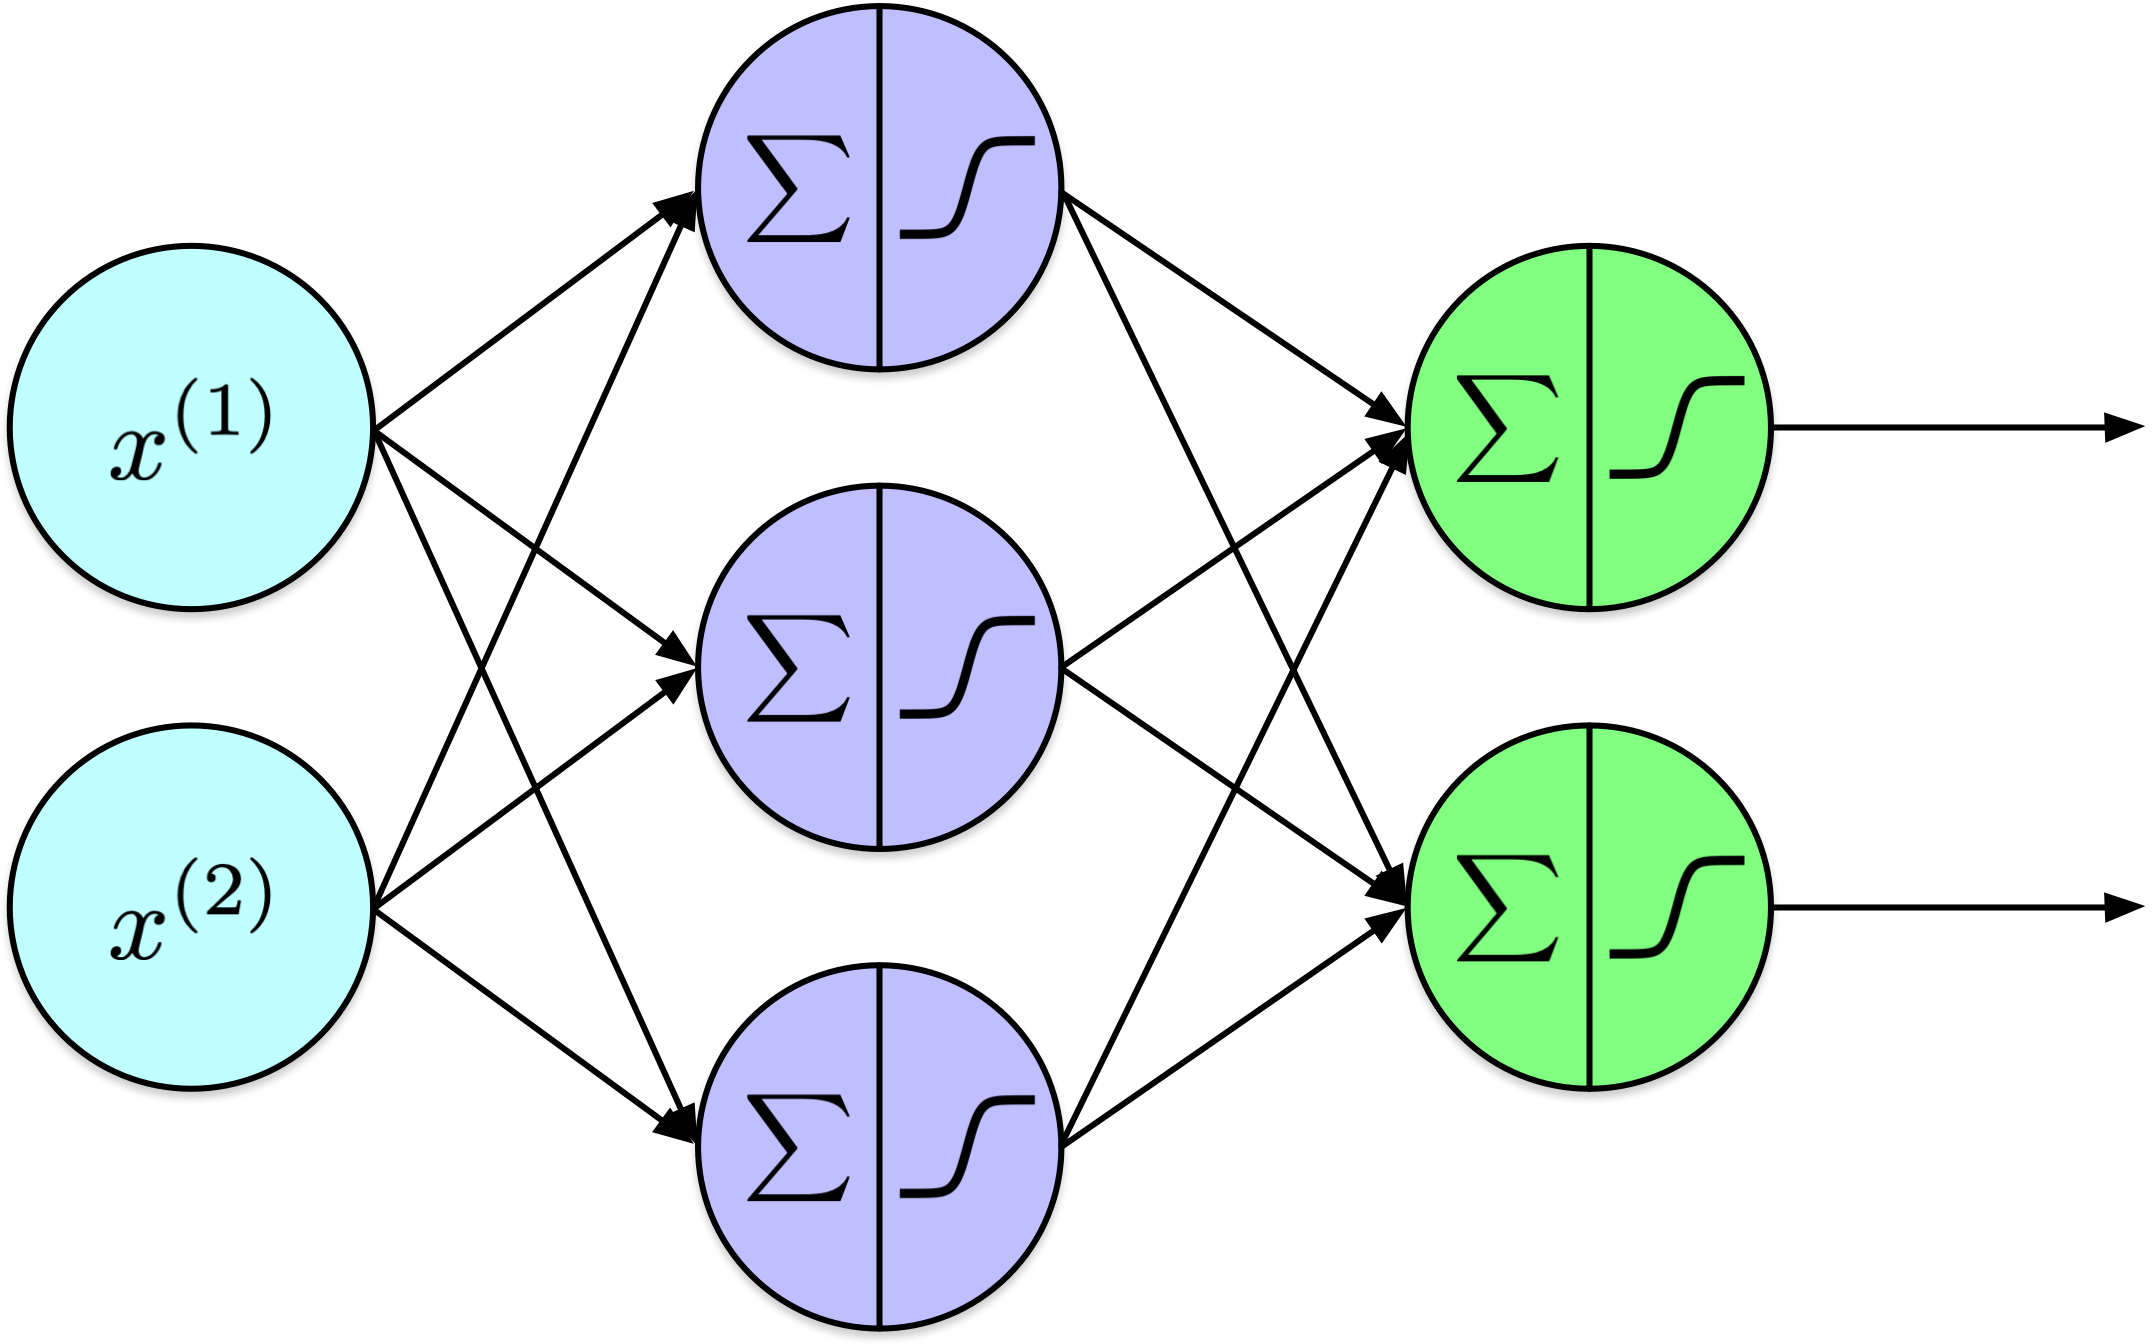

L’information dans cette architecture circule de manière
unidirectionnelle—de gauche à droite, allant de l’entrée à la sortie.
Par conséquent, on l’appelle un **réseau de neurones à propagation avant
(FNN)**.

Les réseaux de neurones ont des **entrées** et des **sorties**.

Le réseau se compose de **trois couches** : entrée, cachée et sortie. La
**couche d’entrée** contient deux nœuds, la **couche cachée** comprend
trois nœuds, et la **couche de sortie** a deux nœuds. Des couches
cachées supplémentaires et des nœuds par couche peuvent être ajoutés, ce
qui sera discuté plus tard.

Il est souvent utile d’inclure des nœuds d’entrée explicites qui ne
réalisent pas de calculs, appelés **unités d’entrée** ou **neurones
d’entrée**. Ces nœuds agissent comme des espaces réservés pour
introduire des caractéristiques d’entrée dans le réseau, passant les
données directement à la couche suivante sans transformation. Dans le
diagramme du réseau, ce sont les nœuds bleu clair à gauche. Typiquement,
**le nombre d’unités d’entrée correspond au nombre de
caractéristiques**.

## Résumé - FNN

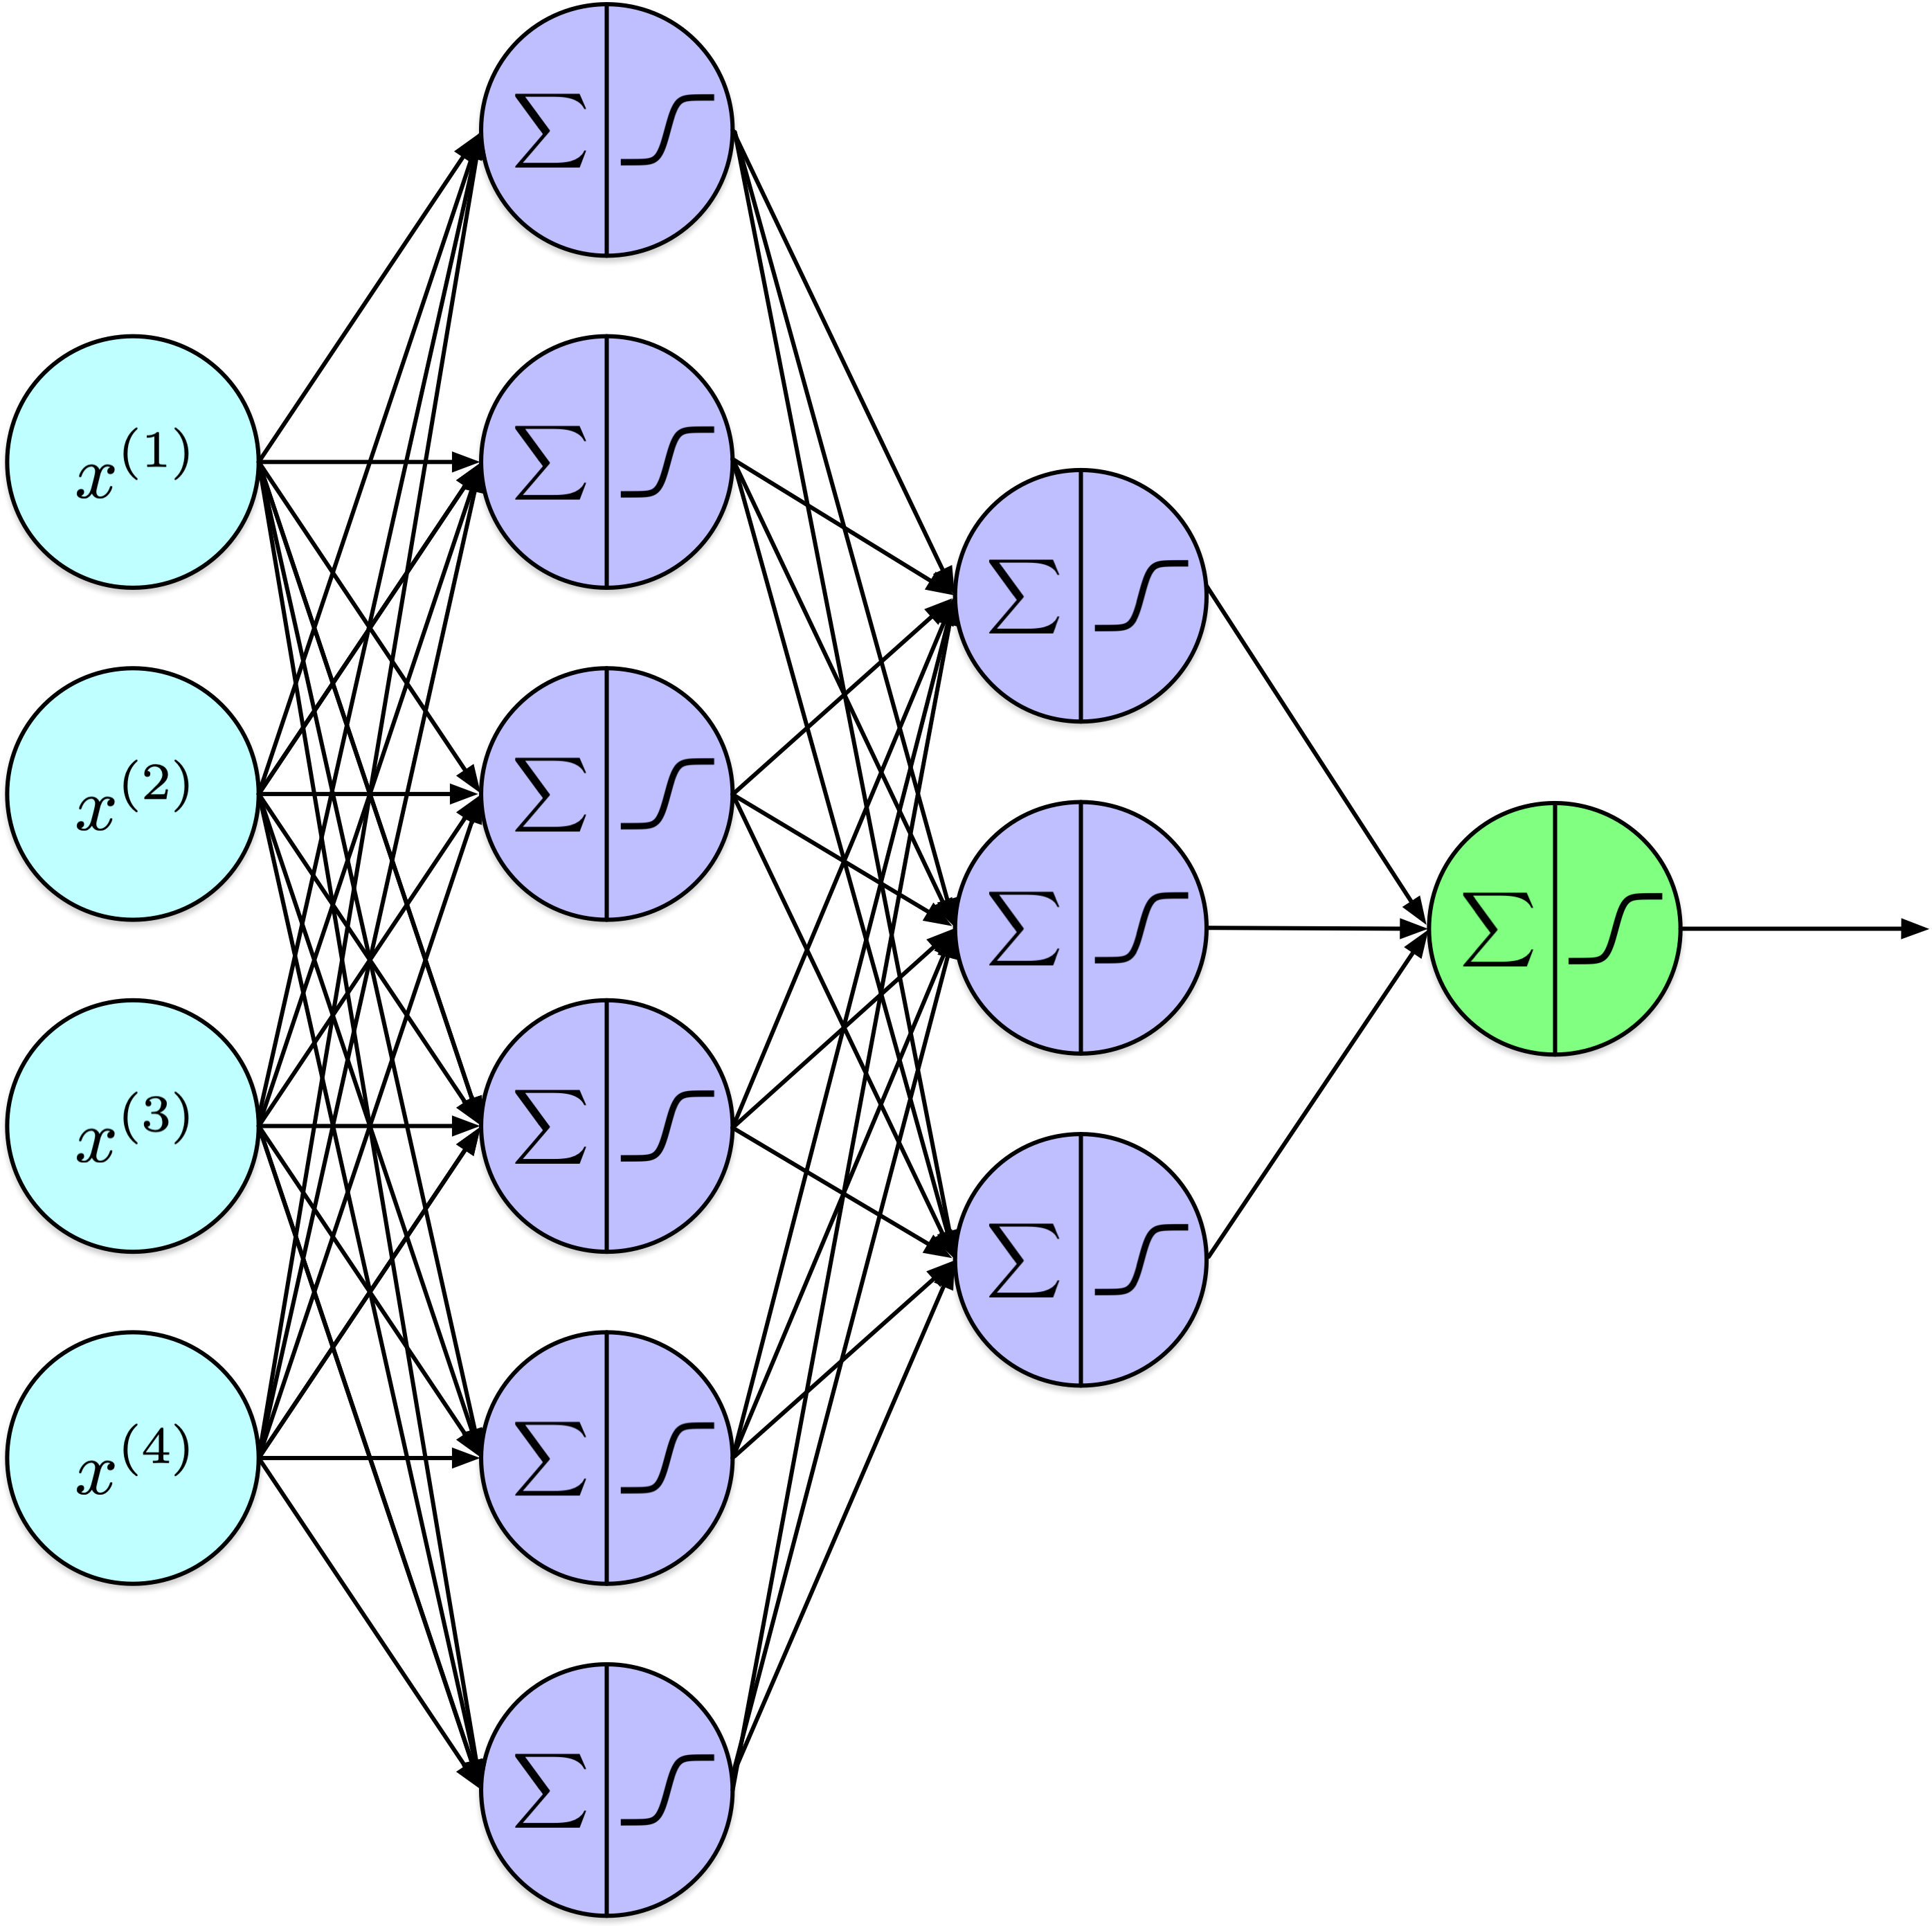

Le nombre de **couches** et de **nœuds** peut varier en fonction des
exigences spécifiques.

Les réseaux de neurones peuvent avoir un nombre de nœuds d’entrée très
important, souvent de l’ordre de plusieurs centaines ou milliers, selon
la complexité des données. De plus, ils peuvent contenir de nombreuses
couches cachées. Par exemple, ResNet, qui a remporté la tâche de
classification d’images ILSVRC 2015, comporte 152 couches. Les auteurs
de ResNet ont démontré des résultats pour des réseaux de 100 et même
1000 couches (He et al. 2016). Cependant, le nombre de nœuds de sortie
tend à être relativement petit. Dans les problèmes de régression, il y a
généralement un seul nœud de sortie, tandis que dans les tâches de
classification (qu’elles soient multiclasses ou multilabel), le nombre
de nœuds de sortie correspond au nombre de classes.

Considérons un scénario dans lequel on peut déterminer le nombre optimal
de couches et de nœuds pour un réseau de neurones. Les preuves
empiriques suggèrent que ces réseaux excellent dans l’exécution des
tâches de classification et de régression. Malgré la complexité
résultant d’un grand nombre de paramètres, qui complique
l’interprétation des motifs appris, comprendre le passage avant,
c’est-à-dire comment le réseau génère des prédictions à partir de
nouvelles données d’entrée, est relativement simple.

L’objectif d’aujourd’hui est de comprendre le processus d’ajustement des
poids du réseau en fonction de sa sortie actuelle. Plus précisément,
nous visons à comprendre comment utiliser le signal de sortie pour
propager l’information en retour à travers le réseau.

## Résumé - unités

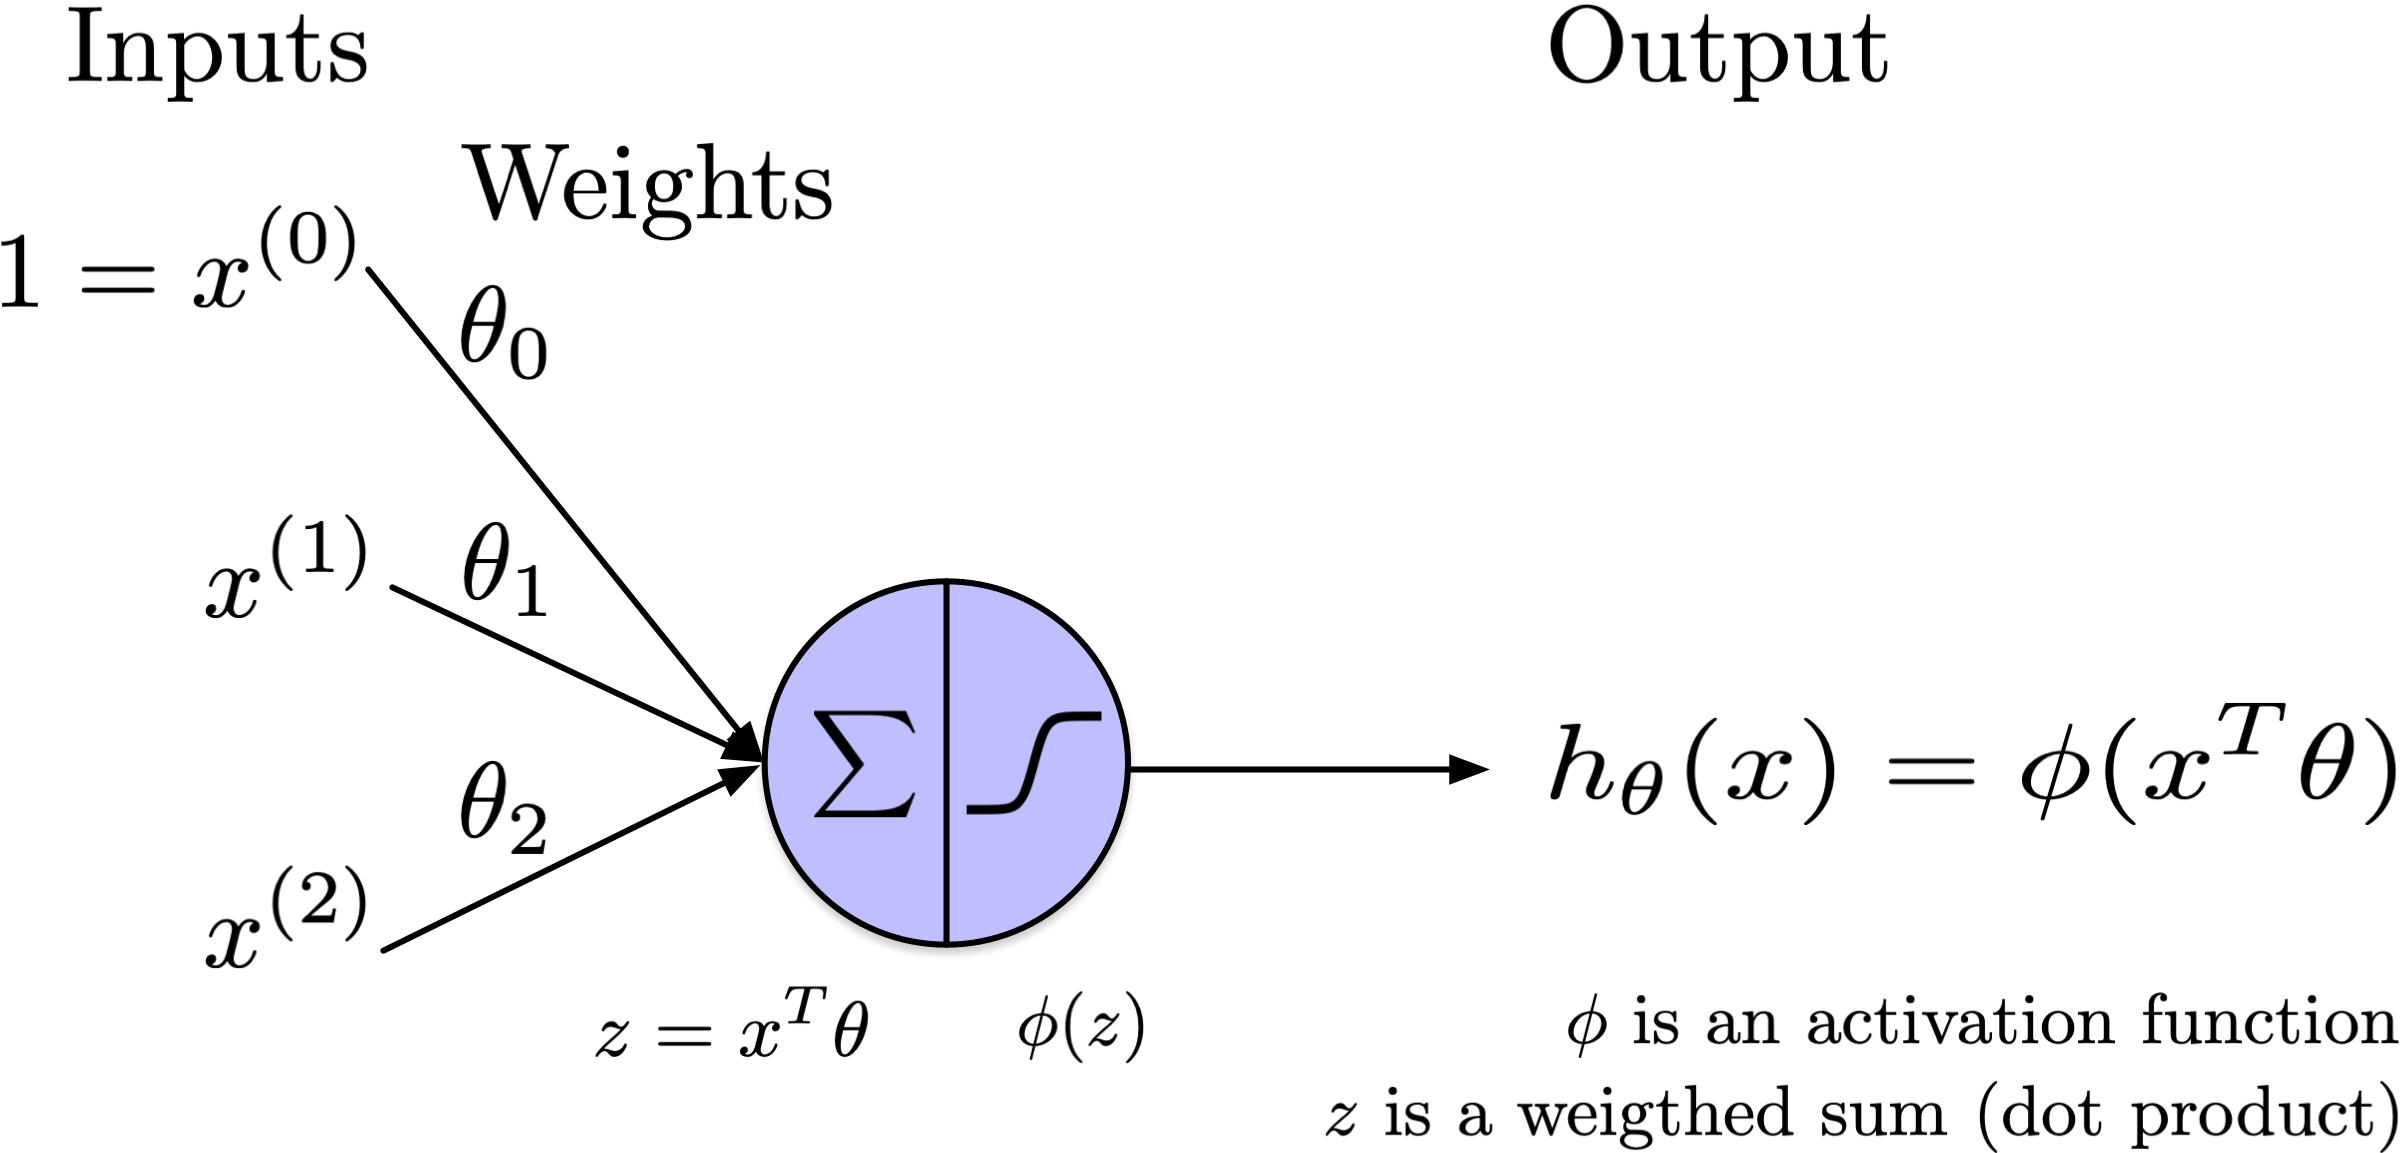

Introduire un input fictif $x^{(0)} = 1$ est une *astuce* qui simplifie
l’expression $x^T\theta + b$.

Dans le schéma ci-dessus, il est important de préciser que les entrées
et la sortie concernent spécifiquement cette unité individuelle, et non
les entrées et la sortie globales de tout le réseau.

Le nom **activation** provient du rôle de la fonction qui détermine si
un neurone doit être “activé” ou “déclenché” en fonction de son entrée.

Historiquement, le concept s’inspire des neurones biologiques, où un
neurone s’active et transmet un signal à d’autres neurones si son entrée
dépasse un certain seuil. Dans les réseaux de neurones artificiels, la
fonction d’activation remplit un rôle similaire en introduisant de la
non-linéarité dans le modèle. Cette non-linéarité est cruciale car elle
permet au réseau d’apprendre des schémas et des représentations
complexes dans les données.

## Fonctions d’activation courantes

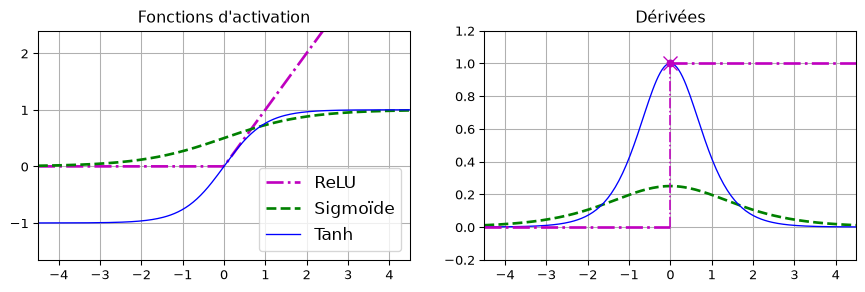

In [2]:
# Attribution: https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb

import numpy as np
import matplotlib.pyplot as plt

from scipy.special import expit as sigmoid

def relu(z):
    return np.maximum(0, z)

def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps))/(2 * eps)

max_z = 4.5
z = np.linspace(-max_z, max_z, 200)

plt.figure(figsize=(11, 3.1))

plt.subplot(121)
plt.plot(z, relu(z), "m-.", linewidth=2, label="ReLU")
plt.plot(z, sigmoid(z), "g--", linewidth=2, label="Sigmoïde")
plt.plot(z, np.tanh(z), "b-", linewidth=1, label="Tanh")
plt.grid(True)
plt.title("Fonctions d'activation")
plt.axis([-max_z, max_z, -1.65, 2.4])
plt.gca().set_yticks([-1, 0, 1, 2])
plt.legend(loc="lower right", fontsize=13)

plt.subplot(122)
plt.plot(z, derivative(sigmoid, z), "g--", linewidth=2, label="Sigmoïde")
plt.plot(z, derivative(np.tanh, z), "b-", linewidth=1, label="Tanh")
plt.plot([-max_z, 0], [0, 0], "m-.", linewidth=2)
plt.plot([0, max_z], [1, 1], "m-.", linewidth=2)
plt.plot([0, 0], [0, 1], "m-.", linewidth=1.2)
plt.plot(0, 1, "mo", markersize=5)
plt.plot(0, 1, "mx", markersize=10)
plt.grid(True)
plt.title("Dérivées")
plt.axis([-max_z, max_z, -0.2, 1.2])

plt.show()

Géron (2022) –
[10_neural_nets_with_keras.ipynb](https://github.com/ageron/handson-ml3/blob/main/10_neural_nets_with_keras.ipynb)

Considérez les observations suivantes :

- La fonction sigmoïde produit des sorties dans l’intervalle ouvert
  $(0, 1)$.
- La fonction tangente hyperbolique ($\tanh$) a une image couvrant
  l’intervalle ouvert $(-1, 1)$.
- La fonction unitaire linéaire rectifiée (ReLU) produit des valeurs
  dans l’intervalle $[0, \infty)$.

De plus, notez :

- La valeur maximale de la dérivée de la fonction sigmoïde est 0.25.
- La valeur maximale de la dérivée de la fonction $\tanh$ est 1.
- La dérivée de la fonction ReLU est 0 pour les entrées négatives et 1
  pour les entrées positives.

En outre :

- Un nœud utilisant ReLU comme fonction d’activation génère des sorties
  dans la plage $[0, \infty)$. Cependant, sa dérivée, utilisée dans la
  descente de gradient lors de la rétropropagation, est constante,
  prenant les valeurs de 0 ou 1.

## Approximation Universelle

Le **théorème d’approximation universelle** affirme qu’un réseau de
neurones feed-forward avec une seule couche cachée contenant un nombre
fini de neurones peut **approximer n’importe quelle fonction continue**
sur un sous-ensemble compact de $\mathbb{R}^n$, moyennant des poids et
des fonctions d’activation appropriés.

Cybenko (1989); Hornik et al. (1989)

Le Théorème d’Approximation Universelle (UAT) est une garantie théorique
puissante : en principe, un réseau à une seule couche cachée
suffisamment large peut approximer n’importe quelle fonction continue.
Mais ce n’est pas une prescription pratique. Dans les problèmes réels,
une architecture profonde atteint souvent la même précision
d’approximation avec beaucoup moins de paramètres et de manière plus
formable et généralisable.

- Sous des hypothèses relativement légères (par exemple, activation non
  polynomiale, continuité, domaine d’entrée compact), un réseau de
  neurones feed-forward avec une couche cachée et un nombre suffisamment
  grand de neurones (c’est-à-dire “assez large”) peut approximer
  n’importe quelle fonction continue aussi précisément que souhaité
  (avec une erreur arbitrairement petite) sur un domaine compact.
- Le théorème est typiquement un résultat d’*existence*. Il garantit
  qu’un tel réseau existe, mais ne montre pas comment trouver les bons
  poids (c’est-à-dire la procédure d’entraînement) ni combien de
  neurones sont précisément nécessaires.
- Le théorème ne garantit pas non plus quoi que ce soit concernant la
  généralisation aux données non vues (c’est-à-dire le surapprentissage)
  ou l’efficacité computationnelle de l’entraînement.
- L’UAT dit “il existe un réseau assez large”, mais cela peut nécessiter
  un nombre extrêmement grand de neurones. Dans de nombreux contextes
  pratiques, cela devient infaisable (trop de paramètres, trop lent,
  risque de surapprentissage, etc.).
- Certaines fonctions sont “difficiles” à approximer par des réseaux peu
  profonds (c’est-à-dire à une seule couche cachée) à moins d’utiliser
  un nombre exponentiellement élevé de neurones. En revanche, les
  réseaux plus profonds peuvent approximativement la même fonction avec
  beaucoup moins de paramètres.
- L’UAT suppose que vous pouvez choisir les “bons” poids. Mais dans
  l’entraînement réel, l’optimisation (par exemple via la descente de
  gradient) peut être bloquée dans de mauvais minima locaux, plateaux,
  points de selle, ou échouer à converger vers la solution
  d’approximation.
- Il ne donne aucune garantie sur le nombre d’échantillons
  d’entraînement nécessaires pour réaliser une bonne approximation, ni
  sur la généralisation à de nouvelles données.
- Même si un réseau peut approximer exactement une fonction cible (sur
  les données d’entraînement), il peut mal généraliser si le modèle est
  sur-paramétré ou si la régularisation est insuffisante.
- L’UAT est silencieux sur la robustesse au bruit, la stabilité, ou
  l’extrapolation en dehors du domaine d’entraînement.

# MLP Naïf

## Données

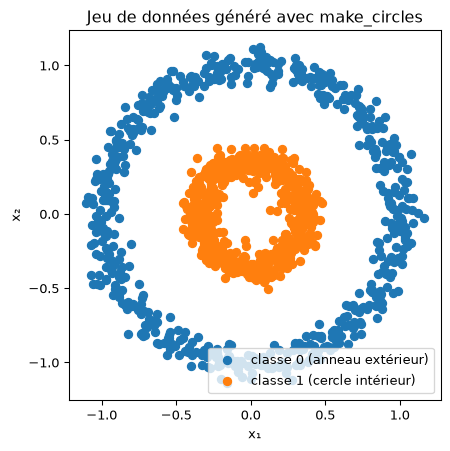

In [3]:
# Générer et tracer le jeu de données "cercles"
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# Générer des données synthétiques
X, y = make_circles(n_samples=1200, factor=0.35, noise=0.06, random_state=42)

# Séparer les coordonnées pour le tracé
x1, x2 = X[:, 0], X[:, 1]

# Tracer les deux classes
plt.figure(figsize=(5, 5))
plt.scatter(x1[y==0], x2[y==0], color="C0", label="classe 0 (anneau extérieur)")
plt.scatter(x1[y==1], x2[y==1], color="C1", label="classe 1 (cercle intérieur)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Jeu de données généré avec make_circles")
plt.axis("equal") # assure que les cercles ont l'air ronds
plt.legend()
plt.show()

Des concepts tels que les dérivées partielles, la descente de gradient
et la rétropropagation peuvent sembler intimidants au départ. Pour
atténuer cette complexité, nous proposons une approche intermédiaire en
construisant un réseau de neurones simple mais pleinement opérationnel.

Il est important de noter que l’algorithme d’apprentissage proposé n’est
pas destiné à remplacer la méthode standard de rétropropagation utilisée
en pratique.

Nous construisons un jeu de données qui comprend deux classes distinctes
: un anneau extérieur (classe 1) et un cercle intérieur (classe 0). Ces
classes sont délibérément conçues pour être non linéairement séparables
dans l’espace des caractéristiques $(x_1, x_2)$, présentant un scénario
simple mais difficile pour les tâches de classification.

## Architecture

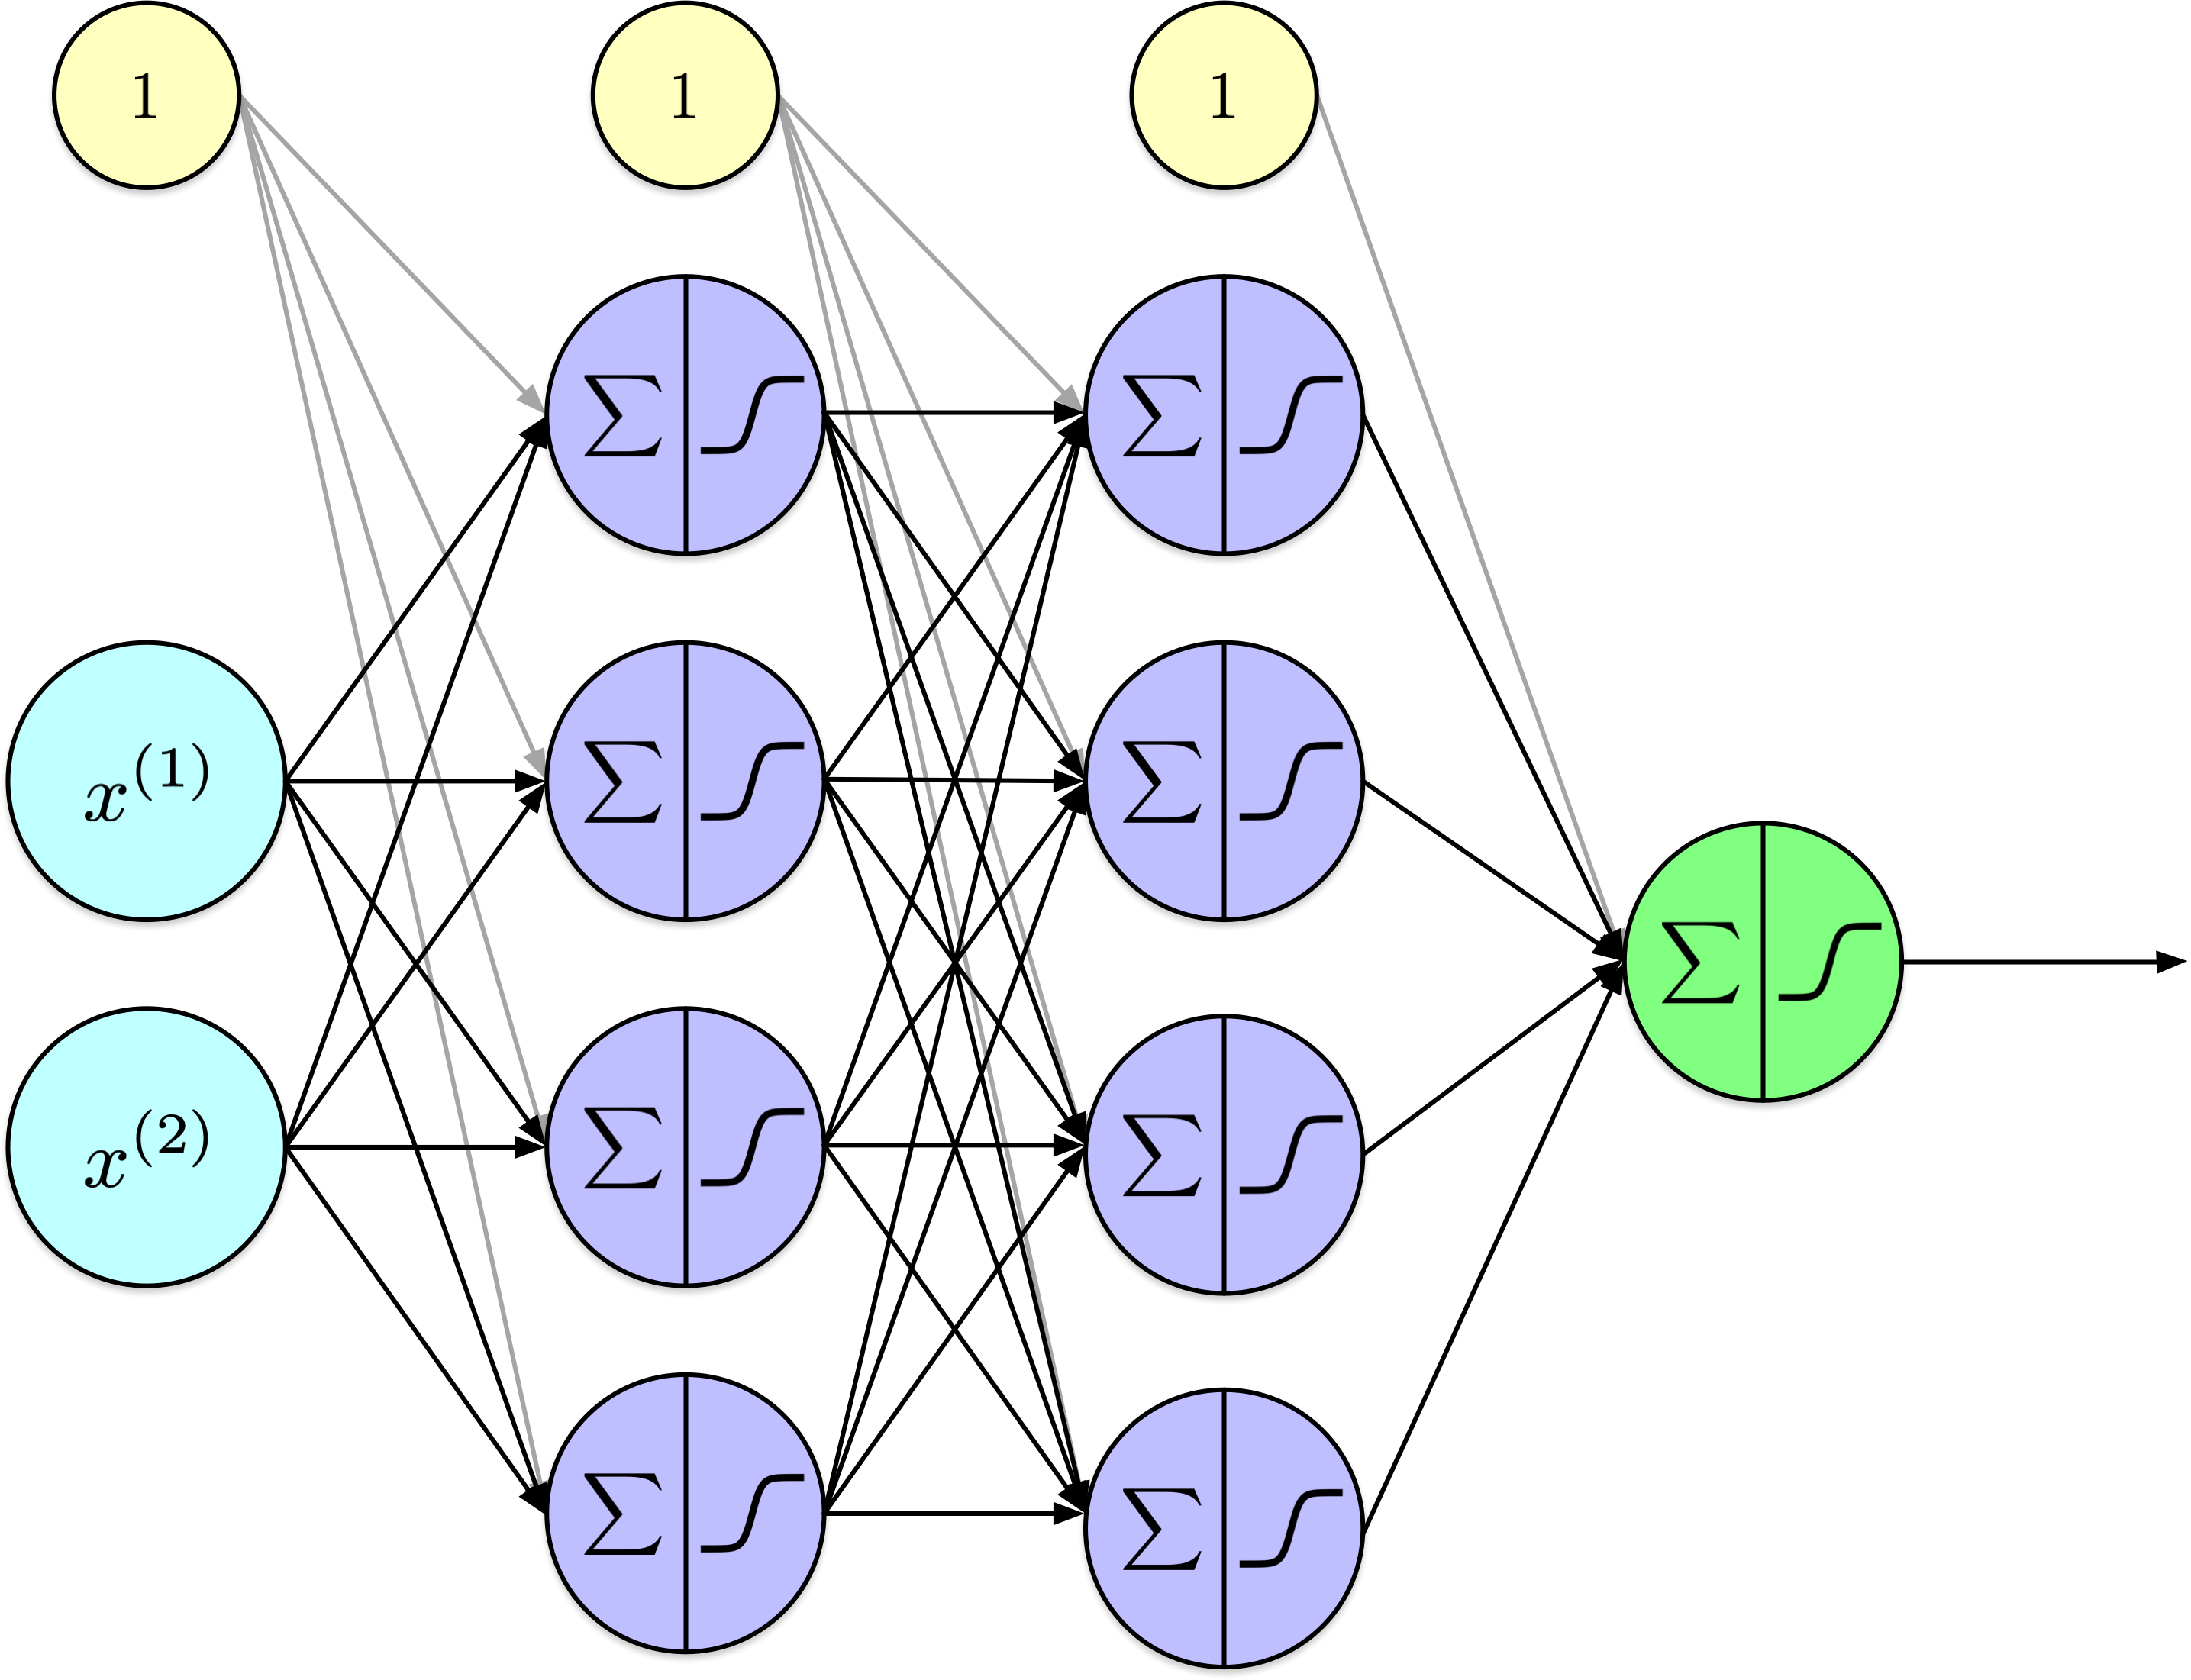

Notre réseau de neurones, un perceptron multicouche, est conçu avec deux
nœuds d’entrée correspondant aux deux caractéristiques présentes dans
notre ensemble de données. À travers nos expérimentations utilisant
TensorFlow Playground et Keras, comme détaillé dans
[CircularSeparability](../11/CircularSeparability), nous avons déterminé
qu’une configuration de deux couches cachées contenant chacune quatre
neurones est efficace pour la classification des échantillons.

Le réseau produit une seule sortie via la fonction d’activation
sigmoïde.

Dans la visualisation, les arêtes noires entre les unités représentent
les poids du modèle. De plus, nous avons inclus trois nœuds qui
produisent une valeur constante de 1 uniquement à des fins de
visualisation ; ces nœuds n’ont pas d’équivalent dans le modèle réel.
Les arêtes grises connectant ces nœuds à d’autres unités représentent
les termes de biais.

## Utilitaires

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(y_true, y_prob, eps=1e-9):

    """Perte d'entropie croisée binaire (moyenne sur les données)."""

    y_prob = np.clip(y_prob, eps, 1 - eps)

    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

Nous définissons deux fonctions utilitaires, `sigmoid` et `bce_loss`. La
perte d’entropie croisée binaire a la même définition que celle de notre
[modèle de régression logistique](../06/slides). Vous souvenez-vous d’un
autre nom pour la perte d’entropie croisée binaire ?

Dans `bce_loss`, les probabilités sont contraintes dans l’intervalle
$[\epsilon, 1-\epsilon]$. Ce clipping permet d’éviter les expressions
logarithmiques $\log(0)$ et $\log(1-1) = \log(0)$, empêchant ainsi des
valeurs indéfinies ou infinies lors du calcul.

Les deux fonctions sont conçues pour prendre en entrée des tableaux
NumPy (`ndarray`). Notamment, la fonction `bce_loss` calcule la perte
pour l’ensemble du jeu de données sans nécessiter une itération
explicite sur les points de données individuels.

## NaïveMLP

L’implémentation complète est présentée ci-dessous et sera examinée dans
les écrans suivants.

In [5]:
class NaiveMLP:

    """
    Un perceptron multicouche minimal (MLP) utilisant un algorithme d'entraînement
    par force brute qui ne nécessite pas de calculs de dérivées.

    Veuillez noter que l'algorithme d'entraînement suggéré est destiné uniquement
    à des fins didactiques et ne doit pas être confondu avec un véritable algorithme d'entraînement.
    """

    def __init__(self, layer_sizes, step=0.1, seed=None):
        
        self.sizes = list(layer_sizes)
        self.step = float(step)
        rng = np.random.default_rng(seed)

        # Initialiser les poids et les biais

        self.W = [rng.standard_normal(size=(in_d, out_d)) * 0.5
                  for in_d, out_d in zip(layer_sizes[:-1], layer_sizes[1:])]

        self.b = [np.zeros(out_d) for out_d in layer_sizes[1:]]

    def forward(self, X):

        """
        Passage avant simple : ne calcule que les activations de sortie.

        X: forme (N, input_dim)

        Retourne : probabilités de sortie, forme (N,)
        """

        a = X
        for W, b in zip(self.W, self.b):
            a = sigmoid(a @ W + b)

        return a.ravel()

    def predict(self, X, threshold=0.5):

        return (self.forward(X) >= threshold).astype(int)

    def loss(self, X, y):

        return bce_loss(y, self.forward(X))

    def _all_param_tags(self):

        """
        Génère des étiquettes référant à chaque paramètre scalaire :
        ('W', layer_idx, i, j) ou ('b', layer_idx, j)
        """

        for l, W in enumerate(self.W):
            for i in range(W.shape[0]):
                for j in range(W.shape[1]):
                    yield ('W', l, i, j)
            for j in range(self.b[l].shape[0]):
                yield ('b', l, j)

    def _get_param(self, tag):
        kind = tag[0]
        if kind == 'W':
            _, l, i, j = tag
            return self.W[l][i, j]
        else:
            _, l, j = tag
            return self.b[l][j]

    def _set_param(self, tag, val):
        kind = tag[0]
        if kind == 'W':
            _, l, i, j = tag
            self.W[l][i, j] = val
        else:
            _, l, j = tag
            self.b[l][j] = val

    def train(self, X, y, epochs=10, verbose=True):

        """
        Mise à jour simultanée :
        - Pour chaque paramètre scalaire θ, essayez θ + δ pour δ dans {−step, 0, +step},
          choisissez le δ qui donne la perte minimale.
        - Collecter tous les δ choisis, puis appliquer toutes les mises à jour ensemble.
        """

        for ep in range(1, epochs + 1):

            base_loss = self.loss(X, y)
            updates = {}

            # Tester tous les paramètres
            for tag in self._all_param_tags():

                theta = self._get_param(tag)
                best_delta = 0.0
                best_loss = base_loss

                for delta in (-self.step, 0.0, +self.step):
                    self._set_param(tag, theta + delta)
                    trial_loss = self.loss(X, y)
                    if trial_loss < best_loss:
                        best_loss = trial_loss
                        best_delta = delta

                # restaurer l'original
                self._set_param(tag, theta)
                updates[tag] = best_delta

            # Appliquer tous les deltas ensemble
            for tag, d in updates.items():
                if d != 0.0:
                    self._set_param(tag, self._get_param(tag) + d)

            new_loss = self.loss(X, y)

            if verbose:
                print(f"Époque {ep:3d} : perte {base_loss:.5f} → {new_loss:.5f}")

            # arrêt précoce optionnel
            if abs(new_loss - base_loss) < 1e-12:
                break

Pour assurer la fonctionnalité du Jupyter Notebook résultant, toute la
classe a été incluse ici.

## Définition de la Classe

In [6]:
class NaiveMLP:

    """
    Un perceptron multicouche (MLP) minimal utilisant un algorithme 
    d'entraînement par force brute qui ne nécessite pas de calcul 
    des dérivées.

    Veuillez noter que l'algorithme d'entraînement proposé est destiné 
    uniquement à des fins didactiques et ne doit pas être confondu avec 
    un véritable algorithme d'entraînement.
    """

## Constructeur

In [7]:
    def __init__(self, layer_sizes, step=0.1, seed=None):
        
        self.sizes = list(layer_sizes)
        self.step = float(step)
        rng = np.random.default_rng(seed)

        # Initialiser les poids et les biais

        self.W = [rng.standard_normal(size=(in_d, out_d)) * 0.5
                  for in_d, out_d in zip(layer_sizes[:-1], layer_sizes[1:])]

        self.b = [np.zeros(out_d) for out_d in layer_sizes[1:]]

Mémoriser le nombre de couches, le nombre d’unités par couche et la
taille du pas de l’algorithme d’apprentissage. Initialiser les poids
($W$) et les biais ($b$).

## Python

In [8]:
seed = 0

rng = np.random.default_rng(seed)

layer_sizes = [2, 4, 4, 1]

[(in_d, out_d) for in_d, out_d in zip(layer_sizes[:-1], layer_sizes[1:])]

[(2, 4), (4, 4), (4, 1)]

. . .

In [9]:
[rng.standard_normal(size=(in_d, out_d)) * 0.5 for in_d, out_d in zip(layer_sizes[:-1], layer_sizes[1:])]

[array([[ 0.06286511, -0.06605243,  0.32021133,  0.05245006],
        [-0.26783469,  0.18079753,  0.65200002,  0.47354048]]),
 array([[-0.35186762, -0.63271074, -0.31163723,  0.02066299],
        [-1.16251539, -0.10939583, -0.62295547, -0.36613368],
        [-0.27212949, -0.15815008,  0.20581527,  0.52125668],
        [-0.06426733,  0.68323174, -0.33259734,  0.17575504]]),
 array([[ 0.45173509],
        [ 0.04700615],
        [-0.37174962],
        [-0.46086269]])]

Combien de poids a ce réseau?

## Python

In [10]:
[out_d for out_d in layer_sizes[1:]]

[4, 4, 1]

. . .

In [11]:
[np.zeros(out_d) for out_d in layer_sizes[1:]]

[array([0., 0., 0., 0.]), array([0., 0., 0., 0.]), array([0.])]

Quel est le nombre de termes de biais dans ce réseau ?

Le réseau se compose d’un total de 37 paramètres, qui incluent 28 poids
et 9 termes de biais.

## Passage Avant

In [12]:
    def forward(self, X):

        """
        Passage avant simple : calculer les activations de sortie.
        X : forme (N, input_dim)
        Retourne : probabilités de sortie, forme (N,)
        """

        a = X
        for W, b in zip(self.W, self.b):
            a = sigmoid(a @ W + b)

        return a.ravel()

Calcul des activations de sortie. Déterminer la probabilité de chaque
instance dans le jeu de données $X$ d’appartenir à la classe 1.

La méthode procède couche par couche, de manière séquentielle. Dans
notre exemple en cours, cela implique trois couches de traitement
distinctes.

**Que sont `W` et `b` ?**

`W` et `b` sont des listes, chacune contenant trois éléments. La liste
`W` comprend des matrices de poids de dimensions $2 \times 4$,
$4 \times 4$, et $4 \times 1$, tandis que `b` se compose de tableaux de
biais de tailles 4, 4, et 1, respectivement.

**Quel est le but de `zip(self.W, self.b)` ?**

Cette fonction associe chaque matrice de poids à son tableau de biais
correspondant, ce qui donne trois tuples, un pour chacune des deuxième,
troisième et quatrième couches.

**Que représente `X` ?**

L’utilisation de `NumPy` rend le code compact, mais il est important de
reconnaître les détails sous-jacents. Le paramètre `X` encapsule
l’ensemble du jeu de données, comprenant 200 échantillons avec 2
caractéristiques chacun. À chaque itération de la boucle, les
activations pour toutes les unités de la couche actuelle sont calculées
pour tous les exemples.

## Faire des prédictions

In [13]:
    def predict(self, X, threshold=0.5):

        return (self.forward(X) >= threshold).astype(int)

En effet, prédictions, au pluriel.

La méthode `forward` produit un tableau de probabilités, chacune variant
de 0 à 1, indiquant la probabilité qu’un exemple particulier, $x_i$,
appartienne à la classe 1. En évaluant l’expression
`self.forward(X) >= threshold`, nous obtenons un tableau de valeurs
booléennes : `True` si la probabilité dépasse le `seuil` spécifié, et
`False` sinon. Ces valeurs booléennes sont ensuite converties en valeurs
binaires de zéros et de uns.

Il est important de noter que le fait d’ajuster la limite de décision,
`threshold`, permet de manipuler le compromis précision-rappel, offrant
ainsi de la flexibilité dans les performances du modèle.

## Calcul du coût

In [14]:
    def loss(self, X, y):

        return bce_loss(y, self.forward(X))

La méthode en question calcule la perte pour l’ensemble du jeu de
données.

Que se passerait-il si nous retournions `bce_loss(y, self.predict(X))`
au lieu de `bce_loss(y, self.forward(X))`?

## Discussion

À l’exception de l’algorithme d’entraînement, notre implémentation de
réseau de neurones est maintenant complète.

Pour ceux qui ne sont pas familiers avec l’algorithme de
rétropropagation, comment proposez-vous d’apprendre les paramètres du
modèle ?

. . .

Changer les poids → calculer la perte → conserver si meilleur → répéter.

## Pseudocode

``` pseudocode
for each epoch:
    deltas = {}  # enregistrer le meilleur delta pour chaque paramètre
    for each parameter w in network:
        best_delta = 0
        best_loss = current_loss  # perte calculée avec les poids actuels
        for delta in [-0.01, 0, +0.01]:
            w_temp = w + delta
            loss_temp = compute_loss_with_replacement(w_temp, w, data)
            if loss_temp < best_loss:
                best_loss = loss_temp
                best_delta = delta
        deltas[w] = best_delta

    # Appliquer toutes les mises à jour simultanément
    for each parameter w in network:
        w += deltas[w]
```

Il est important de noter que cet algorithme est **fondamentalement
distinct de la rétropropagation**, qui est largement utilisée en
pratique. La raison principale de son introduction est sa simplicité,
notamment l’**absence de dérivées partielles**.

L’algorithme fonctionne sur plusieurs époques, au cours desquelles la
précision prédictive pour l’ensemble d’entraînement est progressivement
améliorée à chaque itération.

Lors de chaque itération, l’algorithme évalue s’il faut diminuer,
augmenter ou maintenir la valeur actuelle de chaque paramètre.

Une fois l’ajustement optimal pour chaque paramètre déterminé, tous les
changements sont mis en œuvre simultanément. Cette approche ressemble à
la technique de descente de gradient discutée plus tôt dans le semestre
et offre l’avantage d’une parallélisation simple.

## Python

In [15]:
    def _all_param_tags(self):

        """
        Génère des tags référenciant chaque paramètre scalaire :
        ('W', layer_idx, i, j) ou ('b', layer_idx, j)
        """

        for l, W in enumerate(self.W):
            for i in range(W.shape[0]):
                for j in range(W.shape[1]):
                    yield ('W', l, i, j)
            for j in range(self.b[l].shape[0]):
                yield ('b', l, j)

Le code ci-dessus implémente un générateur, qui est un concept Python
qui semble simple, mais qui est très puissant.

Un **générateur** est un type de fonction qui peut *mettre en pause* son
exécution et *reprendre plus tard*. Il produit une séquence de valeurs,
une à la fois, sans les stocker toutes en mémoire. Vous en créez un en
utilisant le mot-clé `yield`.

Voici un exemple.

``` python
def countdown(n):
    while n > 0:
        yield n      # "yield" une valeur et met en pause
        n -= 1
```

Vous pouvez l’appeler trois fois, puis il lèvera `StopIteration`.

``` python
c = countdown(3)
print(next(c))  # 3
print(next(c))  # 2
print(next(c))  # 1
try:
  print(next(c))
except StopIteration:
    print("Caught StopIteration.")
```

    3
    2
    1
    Caught StopIteration.

Les générateurs sont souvent utilisés dans des boucles `for`.

``` python
for value in countdown(3):
    print(value)
```

    3
    2
    1

Les fonctions `enumerate` et `zip` renvoient toutes deux des itérateurs,
qui fonctionnent de manière similaire aux générateurs en facilitant
l’évaluation paresseuse. Cette approche génère des éléments
dynamiquement pendant l’itération, évitant ainsi le besoin de stocker
tous les éléments en mémoire simultanément.

## Python

In [19]:
class Demo:

    def __init__(self, layer_sizes):
        self.sizes = list(layer_sizes)
        rng = np.random.default_rng(0)
        self.W = [rng.standard_normal(size=(in_d, out_d)) * 0.5
                  for in_d, out_d in zip(layer_sizes[:-1], layer_sizes[1:])]
        self.b = [np.zeros(out_d) for out_d in layer_sizes[1:]]

    def _all_param_tags(self):

        """
        Génère des étiquettes référenciant chaque paramètre scalaire :
        ('W', layer_idx, i, j) ou ('b', layer_idx, j)
        """

        for l, W in enumerate(self.W):
            for i in range(W.shape[0]):
                for j in range(W.shape[1]):
                    yield ('W', l, i, j)
            for j in range(self.b[l].shape[0]):
                yield ('b', l, j)

    def show(self):

      for tag in self._all_param_tags():
        print(tag)

In [20]:
d = Demo([2,4,4,1])
d.show()

('W', 0, 0, 0)
('W', 0, 0, 1)
('W', 0, 0, 2)
('W', 0, 0, 3)
('W', 0, 1, 0)
('W', 0, 1, 1)
('W', 0, 1, 2)
('W', 0, 1, 3)
('b', 0, 0)
('b', 0, 1)
('b', 0, 2)
('b', 0, 3)
('W', 1, 0, 0)
('W', 1, 0, 1)
('W', 1, 0, 2)
('W', 1, 0, 3)
('W', 1, 1, 0)
('W', 1, 1, 1)
('W', 1, 1, 2)
('W', 1, 1, 3)
('W', 1, 2, 0)
('W', 1, 2, 1)
('W', 1, 2, 2)
('W', 1, 2, 3)
('W', 1, 3, 0)
('W', 1, 3, 1)
('W', 1, 3, 2)
('W', 1, 3, 3)
('b', 1, 0)
('b', 1, 1)
('b', 1, 2)
('b', 1, 3)
('W', 2, 0, 0)
('W', 2, 1, 0)
('W', 2, 2, 0)
('W', 2, 3, 0)
('b', 2, 0)

## Python

In [21]:
    def _get_param(self, tag):
        kind = tag[0]
        if kind == 'W':
            _, l, i, j = tag
            return self.W[l][i, j]
        else:
            _, l, j = tag
            return self.b[l][j]

Étant donné un `tag`, soit `('W', l, i, j)` ou `('b', l, j)`, la méthode
récupère le poids ou le biais correspondant aux indices fournis. `l`
désigne la **couche**; `i` et `j` sont les indices de ligne et de
colonne de `W[l]`, ou `j` est un indice dans `b[l]`.

## Python

In [22]:
    def _set_param(self, tag, val):
        kind = tag[0]
        if kind == 'W':
            _, l, i, j = tag
            self.W[l][i, j] = val
        else:
            _, l, j = tag
            self.b[l][j] = val

Logique similaire, mais la méthode met à jour `self.W[l][i, j]` ou
`self.b[l][j] = val`, selon le type de tag.

## Entraînement (apprentissage)

In [23]:
    def train(self, X, y, epochs=10, verbose=True):

        for ep in range(1, epochs + 1):

            base_loss = self.loss(X, y)
            updates = {}

            # Examiner tous les paramètres
            for tag in self._all_param_tags():

                theta = self._get_param(tag)
                best_delta = 0.0
                best_loss = base_loss

                for delta in (-self.step, 0.0, +self.step):
                    self._set_param(tag, theta + delta)
                    trial_loss = self.loss(X, y)
                    if trial_loss < best_loss:
                        best_loss = trial_loss
                        best_delta = delta

                # restaurer l'original
                self._set_param(tag, theta)
                updates[tag] = best_delta

            # Appliquer tous les deltas ensemble
            for tag, d in updates.items():
                if d != 0.0:
                    self._set_param(tag, self._get_param(tag) + d)

            new_loss = self.loss(X, y)

            if verbose:
                print(f"Époque {ep:3d}: perte {base_loss:.5f} → {new_loss:.5f}")

            # arrêt anticipé optionnel
            if abs(new_loss - base_loss) < 1e-12:
                break

“Simultané” ≈ une étape de style Jacobi : vous choisissez des deltas par
paramètre par rapport à la même ligne de base, puis vous les appliquez
tous en même temps. Les interactions entre les paramètres sont ignorées
pendant que vous les choisissez.

## Ouf!

Est-ce que ça fonctionne ?

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = NaiveMLP([2, 4, 4, 1], step=0.06, seed=0)

print("Loss initiale :", model.loss(X_train, y_train))

model.train(X_train, y_train, epochs=100)

print("Exactitude sur l'entraînement :", accuracy_score(y_train, model.predict(X_train)))
print("Exactitude sur le test :", accuracy_score(y_test, model.predict(X_test)))

Loss initiale : 0.7001969055705487
Époque   1 : perte 0.70020 → 0.69315
Époque   2 : perte 0.69315 → 0.69547
Époque   3 : perte 0.69547 → 0.69387
Époque   4 : perte 0.69387 → 0.69542
Époque   5 : perte 0.69542 → 0.69384
Époque   6 : perte 0.69384 → 0.69537
Époque   7 : perte 0.69537 → 0.69382
Époque   8 : perte 0.69382 → 0.69531
Époque   9 : perte 0.69531 → 0.69379
Époque  10 : perte 0.69379 → 0.69525
Époque  11 : perte 0.69525 → 0.69361
Époque  12 : perte 0.69361 → 0.69517
Époque  13 : perte 0.69517 → 0.69331
Époque  14 : perte 0.69331 → 0.69503
Époque  15 : perte 0.69503 → 0.69298
Époque  16 : perte 0.69298 → 0.69468
Époque  17 : perte 0.69468 → 0.69257
Époque  18 : perte 0.69257 → 0.69364
Époque  19 : perte 0.69364 → 0.69200
Époque  20 : perte 0.69200 → 0.69173
Époque  21 : perte 0.69173 → 0.69118
Époque  22 : perte 0.69118 → 0.68965
Époque  23 : perte 0.68965 → 0.68970
Époque  24 : perte 0.68970 → 0.68716
Époque  25 : perte 0.68716 → 0.68672
Époque  26 : perte 0.68672 → 0.68417
Épo

Notre algorithme d’entraînement est fragile. Obtenir ces résultats a
nécessité d’expérimenter avec `step` et `seed`.

## Visualisation

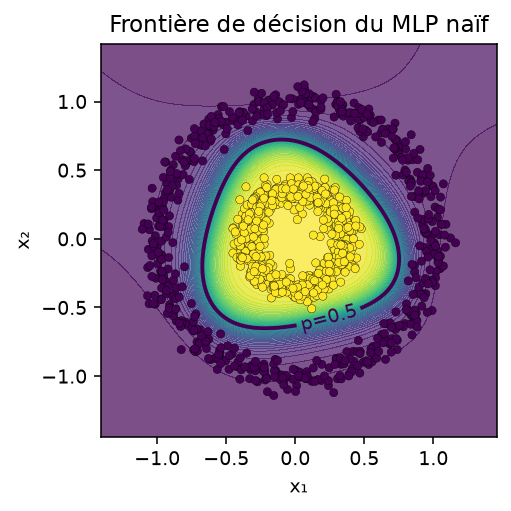

In [25]:
# Plot helper: decision boundary in the original (x1, x2) plane

def plot_decision_boundary(model, X, y, title="Frontière de décision du MLP naïf"):

    # grille sur le plan d'entrée
    pad = 0.3
    x1_min, x1_max = X[:,0].min()-pad, X[:,0].max()+pad
    x2_min, x2_max = X[:,1].min()-pad, X[:,1].max()+pad

    xx, yy = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # prédire les probabilités sur la grille
    p = model.forward(grid).reshape(xx.shape)

    # probabilités remplies + contour p=0.5 + points de données
    plt.figure(figsize=(3.75, 3.75), dpi=140)
    plt.contourf(xx, yy, p, levels=50, alpha=0.7)
    cs = plt.contour(xx, yy, p, levels=[0.5], linewidths=2)
    plt.scatter(X[:,0], X[:,1], c=y, s=18, edgecolor="k", linewidth=0.2)
    plt.clabel(cs, fmt={0.5: "p=0.5"})
    plt.title(title)
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(model, X, y)

## Données de type XOR

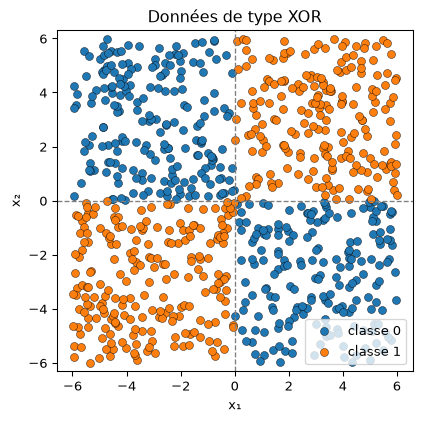

In [26]:
n_samples = 800
rng = np.random.default_rng(42)

X = rng.uniform(-6, 6, size=(n_samples, 2))
x1, x2 = X[:, 0], X[:, 1]

y = ((x1 * x2) > 0).astype(int)

plt.figure(figsize=(4.5, 4.5))
plt.scatter(X[y == 0, 0], X[y == 0, 1],
            color="C0", label="classe 0", edgecolor="k", linewidth=0.3)
plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color="C1", label="classe 1", edgecolor="k", linewidth=0.3)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Données de type XOR")
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

La même architecture, 2, 4, 4, 1, fonctionnerait-elle pour le jeu de
données de type XOR ?

## Données de type XOR (suite)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = NaiveMLP([2, 4, 4, 1], step=0.06, seed=0)

print("Perte initiale :", model.loss(X_train, y_train))

model.train(X_train, y_train, epochs=1000, verbose=False)

print("Perte finale :", model.loss(X_train, y_train))

print("Exactitude sur l'ensemble d'entraînement :", accuracy_score(y_train, model.predict(X_train)))
print("Exactitude sur l'ensemble de test :", accuracy_score(y_test, model.predict(X_test)))

Perte initiale : 0.7029764953722529
Perte finale : 3.4494531195516116e-07
Exactitude sur l'ensemble d'entraînement : 1.0
Exactitude sur l'ensemble de test : 0.99

## Données de type XOR (suite)

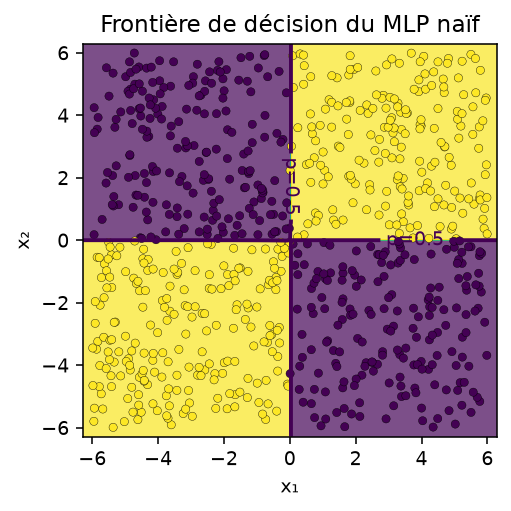

In [28]:
plot_decision_boundary(model, X, y)

Notre réseau neuronal simple, ainsi que son algorithme d’entraînement
naïf, a été évalué sur deux tests distincts. Malgré la simplicité du
modèle, il a réussi à apprendre des frontières de décision
significativement différentes sans nécessiter l’ingénierie de
fonctionnalités supplémentaires.

Pour la simplicité et la clarté dans cet exemple, nous avons utilisé les
données brutes sans appliquer de mise à l’échelle. Cependant, dans des
scénarios pratiques, il est courant de mettre à l’échelle ou de
normaliser les caractéristiques avant d’entraîner des réseaux neuronaux
ou tout modèle reposant sur l’optimisation par gradient. La mise à
l’échelle facilite une convergence plus rapide et plus stable des
algorithmes d’entraînement, bien qu’elle introduise des étapes de
prétraitement et de post-traitement supplémentaires. Puisque l’objectif
principal ici est de comprendre le mécanisme d’entraînement plutôt que
d’optimiser pour l’efficacité, nous avons délibérément choisi de ne pas
inclure la mise à l’échelle dans ce cas.

Avant l’entraînement,

``` python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)
```

Après l’entraînement, lorsque vous souhaitez visualiser la frontière de
décision dans l’espace des caractéristiques d’origine, vous devez
redimensionner les coordonnées à l’aide de `scaler.inverse_transform`.

## Inconvénients

- Inefficacité computationnelle.
- Limitations de scalabilité.
- Taille de pas fixe (±η) manque d’adaptabilité.
- Mauvaise coordination des paramètres.
- Absence d’informations sur la direction ou la magnitude.
- Absence de fonctionnalités sophistiquées de l’optimiseur.
- Risque de sur-apprentissage ou de mauvaise généralisation.

- Inefficacité computationnelle : essayer chaque paramètre avec trois
  deltas à chaque époque s’adapte mal à mesure que la taille du modèle
  augmente.
- Taille de pas fixe (±η) manque d’adaptabilité : trop petit → très lent
  ; trop grand → dépassement/oscillation.
- Mauvaise coordination des paramètres : chaque paramètre est mis à jour
  sans tenir compte des interactions → convergence plus lente dans les
  réseaux couplés.
- Recherche locale discrète (plutôt que basée sur les dérivées) :
  absence d’informations sur la direction ou la magnitude → de
  nombreuses époques nécessaires, risque de zigzag ou de blocage.
- Limitations de scalabilité : évaluation complète de la perte par
  changement de paramètre → infaisable pour de grands ensembles de
  données ou de nombreux paramètres.
- Absence de fonctionnalités sophistiquées de l’optimiseur : pas de
  momentum, de taux adaptatifs, de régularisation intégrée → performance
  et fiabilité réduites.
- Risque de sur-apprentissage ou de mauvaise généralisation :
  entraînement agressif sur la perte complète du lot sans régularisation
  intégrée peut trop s’adapter aux données d’entraînement.
- Aperçu limité de l’ampleur des mises à jour : seules les options ±η ou
  0 signifient pas de réglage fin de la taille de pas par paramètre ou
  époque.

# Notation

## Notation

Un **perceptron à deux couches** calcule :

$$
  \hat{y} = \phi_2(\phi_1(X))
$$

où

$$
  \phi_l(Z) = \phi(W_lZ_l + b_l)
$$

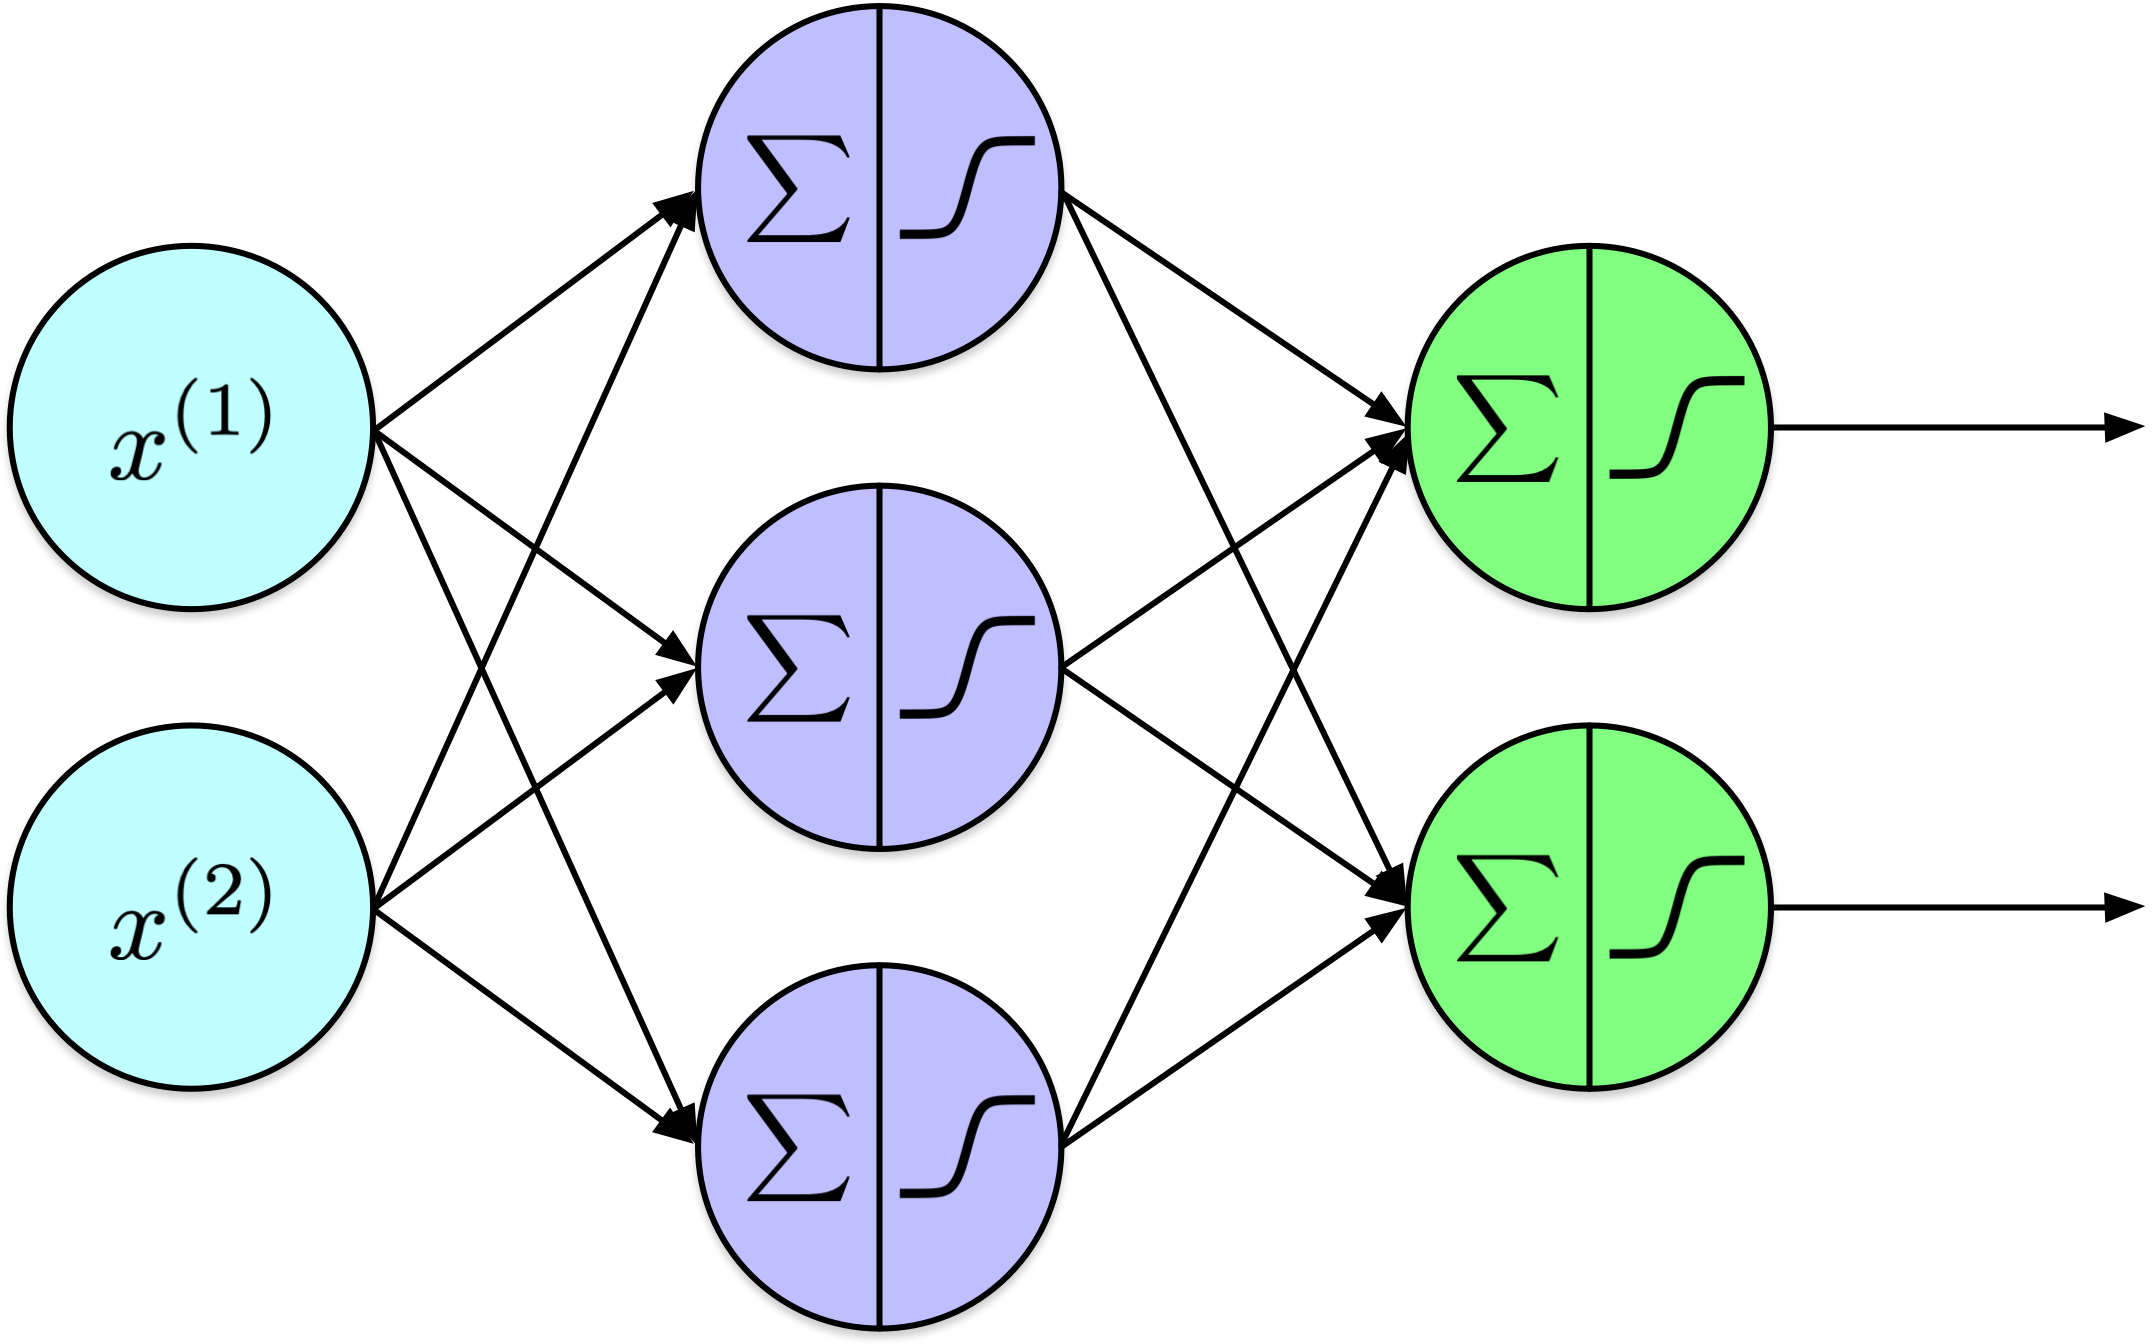

Où $\phi$ est une fonction d’activation, $W$ une matrice de poids, $X$
une matrice d’entrée, et $b$ un vecteur de biais.

## Notation

Un perceptron à **3 couches** calcule :

$$
  \hat{y} = \phi_3(\phi_2(\phi_1(X)))
$$

où

$$
  \phi_l(Z) = \phi(W_lZ_l + b_l)
$$

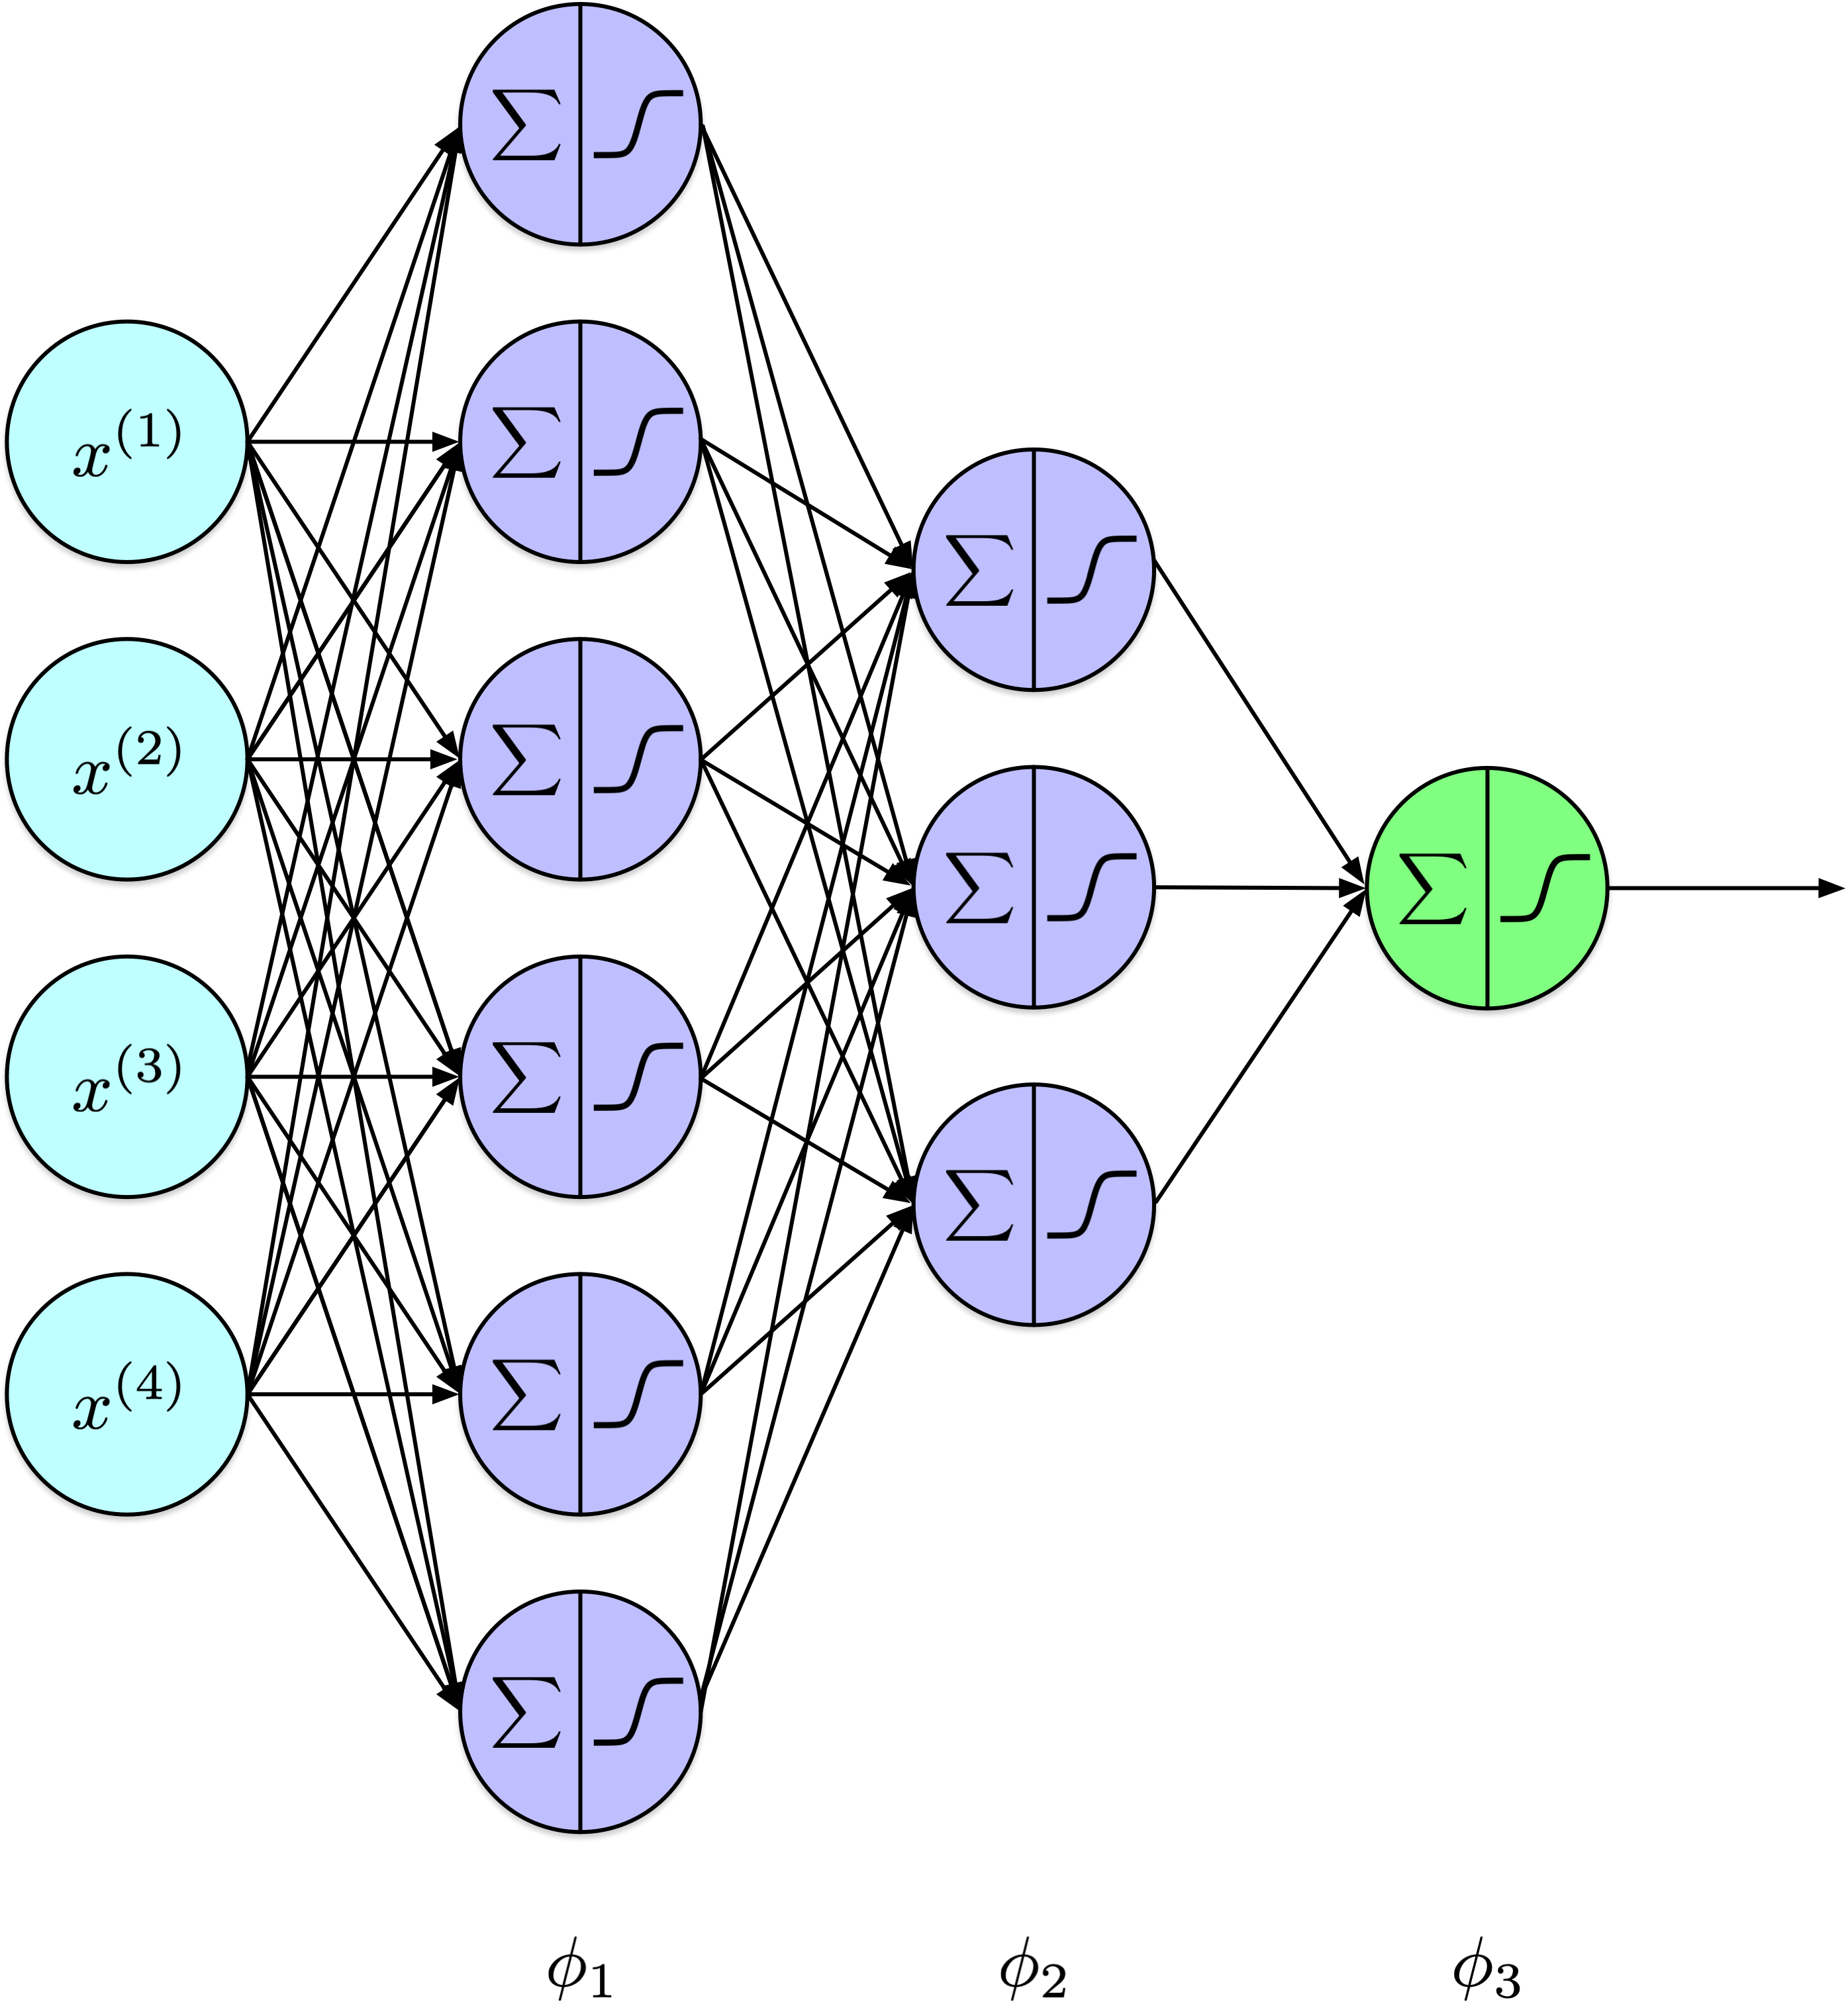

## Notation

Un **perceptron à $k$ couches** calcule :

$$
  \hat{y} = \phi_k( \ldots \phi_2(\phi_1(X)) \ldots )
$$

où

$$
  \phi_l(Z) = \phi(W_lZ_l + b_l)
$$

Un réseau feed-forward présente une structure cohérente, où chaque
couche exécute le même type de calcul sur des entrées variées. Plus
précisément, l’entrée de la couche $l$ est la sortie de la couche $l-1$.

Dans cette notation, il est souligné que seule la première couche reçoit
directement les attributs d’entrée. Chaque couche suivante traite
ensuite les activations de la couche précédente, facilitant
l’apprentissage de nouvelles représentations. Cela met en évidence
l’architecture cohérente des réseaux de neurones à propagation avant.
Comme nous l’explorerons dans le prochain cours, augmenter le nombre de
couches n’augmente pas intrinsèquement la complexité de l’algorithme.

# Prologue

## Résumé

- Présentation de l’apprentissage profond comme une approximation de
  fonction en couches à travers différentes tâches.  
- Description des réseaux de neurones feedforward (FNNs) : entrées →
  couches cachées → sorties ; l’information ne circule que vers
  l’avant.  
- Mention des unités utilisant le biais et les activations ; explication
  de l’importance de la non-linéarité.  
- Revue des plages et du comportement dérivé des fonctions
  sigmoid/tanh/ReLU.  
- Énoncé du Théorème d’Approximation Universelle et de ses limites
  pratiques.  
- Construction d’un petit MLP et calcul des prédictions et de la perte
  BCE sur des données jouets.  
- Démonstration d’un algorithme d’entraînement naïf, non basé sur le
  gradient ; il fonctionnait mais était peu évolutif et fragile.  
- Établissement d’une notation compacte pour les couches,
  $\hat{y} = \phi_k( \ldots \phi_2(\phi_1(X)) \ldots )$ où
  $\phi_l(Z) = \phi(W_lZ_l + b_l)$, en vue de préparer le
  backpropagation.

## Prochain cours

- Nous introduirons le backpropagation, et discuterons du gradient
  évanescent, du softmax et de la régularisation.

## Références

Cybenko, George V. 1989. « Approximation by superpositions of a
sigmoidal function ». *Mathematics of Control, Signals and Systems* 2:
303‑14. <https://api.semanticscholar.org/CorpusID:3958369>.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

He, Kaiming, Xiangyu Zhang, Shaoqing Ren, et Jian Sun. 2016. « Deep
Residual Learning for Image Recognition ». *2016 IEEE Conference on
Computer Vision and Pattern Recognition (CVPR)*, 770‑78.
<https://doi.org/10.1109/CVPR.2016.90>.

Hornik, Kurt, Maxwell Stinchcombe, et Halbert White. 1989. « Multilayer
feedforward networks are universal approximators ». *Neural Networks* 2
(5): 359‑66.
https://doi.org/<https://doi.org/10.1016/0893-6080(89)90020-8>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa